# 02 — Results Visualization

Loads pre-computed arrays from `results/analysis_arrays/` and generates publication-quality figures.

**Figures:**
1. Dimensionality Reduction — Tier 1 (PCA, t-SNE, UMAP, popVAE)
2. Dimensionality Reduction — Tier 2 EAS
3. Top 20 AISNP Ranking
4. Allele Frequency Heatmaps
5. Comprehensive Benchmark (all models)
6. Tier 1 vs Tier 2 Accuracy Drop
7. FREEFORM With/Without Comparison
8. Stacking Ensemble vs Best Single Models
9. Learning Curves (Generative vs Discriminative)
10. Training Time & Inference Latency

## 0. Setup & Style

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Publication quality
matplotlib.rcParams.update({
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "sans-serif",
})
sns.set_style("whitegrid")

PROJECT_ROOT = Path(".").resolve().parent
ARRAY_DIR = PROJECT_ROOT / "results" / "analysis_arrays"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Color palettes
SUPERPOP_COLORS = {"AFR": "#E41A1C", "AMR": "#377EB8", "EAS": "#4DAF4A",
                   "EUR": "#984EA3", "SAS": "#FF7F00"}
EAS_COLORS = {"CDX": "#66C2A5", "CHB": "#FC8D62", "CHS": "#8DA0CB",
              "JPT": "#E78AC3", "KHV": "#A6D854"}

print(f"Loading from: {ARRAY_DIR}")
print(f"Saving to:    {FIG_DIR}")

Loading from: C:\Users\Admin\Uni\BGA-AISNP-NEW\results\analysis_arrays
Saving to:    C:\Users\Admin\Uni\BGA-AISNP-NEW\results\figures


## 1. Load All Saved Arrays

In [ ]:
# --- Label info ---
info = np.load(ARRAY_DIR / "label_info.npz", allow_pickle=True)
superpop_classes = list(info["super_pop_classes"])
eas_classes = list(info["eas_pop_classes"])
snp_ids = list(info["snp_ids"])

y_super = np.load(ARRAY_DIR / "y_super.npy")
y_pop_eas = np.load(ARRAY_DIR / "y_pop_eas.npy")

# --- Dim reduction (Continental) ---
X_pca_cont = np.load(ARRAY_DIR / "dimred_pca_cont.npy")
pca_var_cont = np.load(ARRAY_DIR / "dimred_pca_cont_var.npy")
X_tsne_cont = np.load(ARRAY_DIR / "dimred_tsne_cont.npy")
X_umap_cont = np.load(ARRAY_DIR / "dimred_umap_cont.npy")
Z_cont_2d = np.load(ARRAY_DIR / "dimred_popvae_cont_2d.npy")

# --- Dim reduction (EAS) ---
X_pca_eas = np.load(ARRAY_DIR / "dimred_pca_eas.npy")
pca_var_eas = np.load(ARRAY_DIR / "dimred_pca_eas_var.npy")
X_tsne_eas = np.load(ARRAY_DIR / "dimred_tsne_eas.npy")
X_umap_eas = np.load(ARRAY_DIR / "dimred_umap_eas.npy")
Z_eas_2d = np.load(ARRAY_DIR / "dimred_popvae_eas_2d.npy")

# --- Feature importance ---
fi_t1 = np.load(ARRAY_DIR / "feature_importance_tier1.npz", allow_pickle=True)
fi_t2 = np.load(ARRAY_DIR / "feature_importance_tier2.npz", allow_pickle=True)
af_t1 = pd.read_csv(ARRAY_DIR / "allele_freq_tier1_top20.csv")
af_t2 = pd.read_csv(ARRAY_DIR / "allele_freq_tier2_top20.csv")

# --- Benchmarks ---
df_bench = pd.read_csv(ARRAY_DIR / "benchmark_all_models.csv")
df_ff_t1 = pd.read_csv(ARRAY_DIR / "freeform_comparison_tier1.csv")
df_ff_t2 = pd.read_csv(ARRAY_DIR / "freeform_comparison_tier2.csv")
df_timing = pd.read_csv(ARRAY_DIR / "timing_all_models.csv")

# --- Learning curves ---
lc_t1 = np.load(ARRAY_DIR / "learning_curves_tier1.npz")
lc_t2 = np.load(ARRAY_DIR / "learning_curves_tier2.npz")

print("All arrays loaded successfully.")
print(f"  Benchmark: {len(df_bench)} rows, {df_bench['model'].nunique()} models")
print(f"  Timing: {len(df_timing)} rows")

All arrays loaded successfully.


## Figure 1: Dimensionality Reduction — Continental (Tier 1)
4-panel scatter plots colored by 5 super-populations (AFR, AMR, EAS, EUR, SAS).

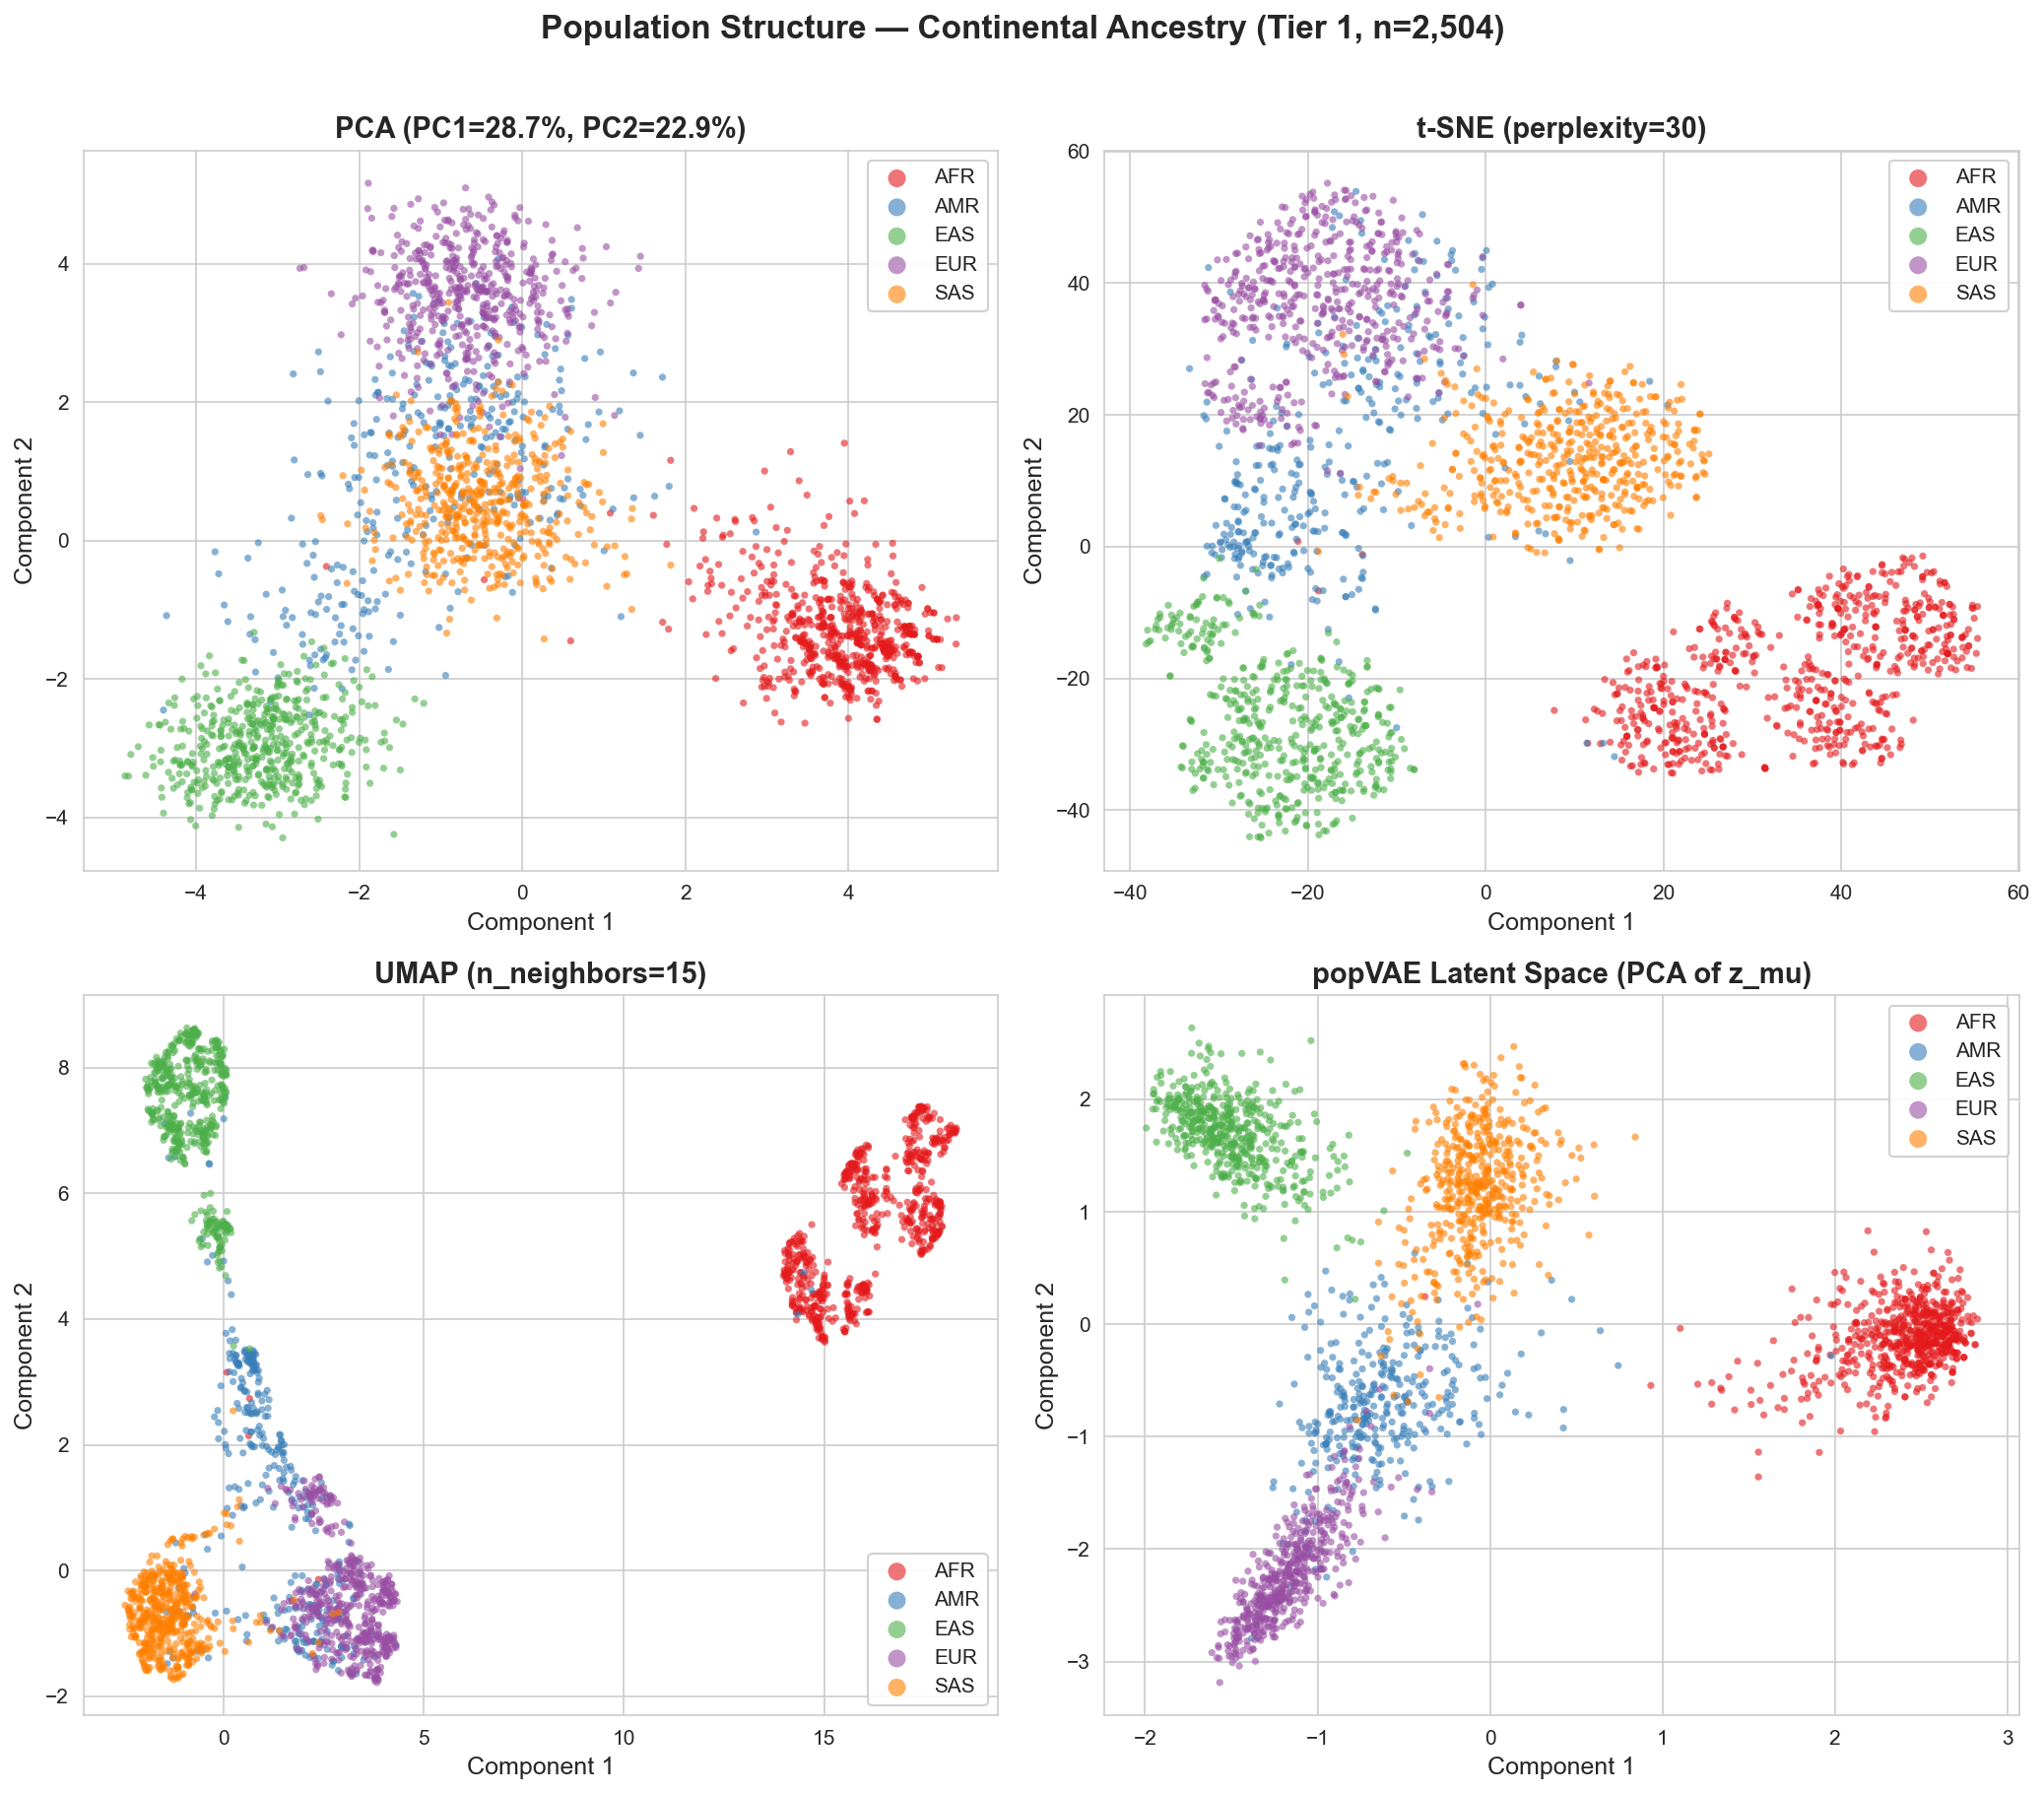

Saved fig1_dimred_tier1.png


In [5]:
labels_cont = np.array([superpop_classes[i] for i in y_super])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
embeddings = [
    (X_pca_cont, f"PCA (PC1={pca_var_cont[0]:.1%}, PC2={pca_var_cont[1]:.1%})"),
    (X_tsne_cont, "t-SNE (perplexity=30)"),
    (X_umap_cont, "UMAP (n_neighbors=15)"),
    (Z_cont_2d, "popVAE Latent Space (PCA of z_mu)"),
]

for ax, (data, title) in zip(axes.flat, embeddings):
    for cls in superpop_classes:
        mask = labels_cont == cls
        ax.scatter(data[mask, 0], data[mask, 1], label=cls,
                   c=SUPERPOP_COLORS[cls], alpha=0.6, s=12, edgecolors="none")
    ax.set_title(title, fontweight="bold")
    ax.legend(markerscale=2.5, framealpha=0.9, loc="best")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

fig.suptitle("Population Structure — Continental Ancestry (Tier 1, n=2,504)",
             fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_dimred_tier1.png")
plt.show()
print("Saved fig1_dimred_tier1.png")

## Figure 2: Dimensionality Reduction — East Asia (Tier 2)
4-panel scatter plots for EAS sub-populations (CDX, CHB, CHS, JPT, KHV).

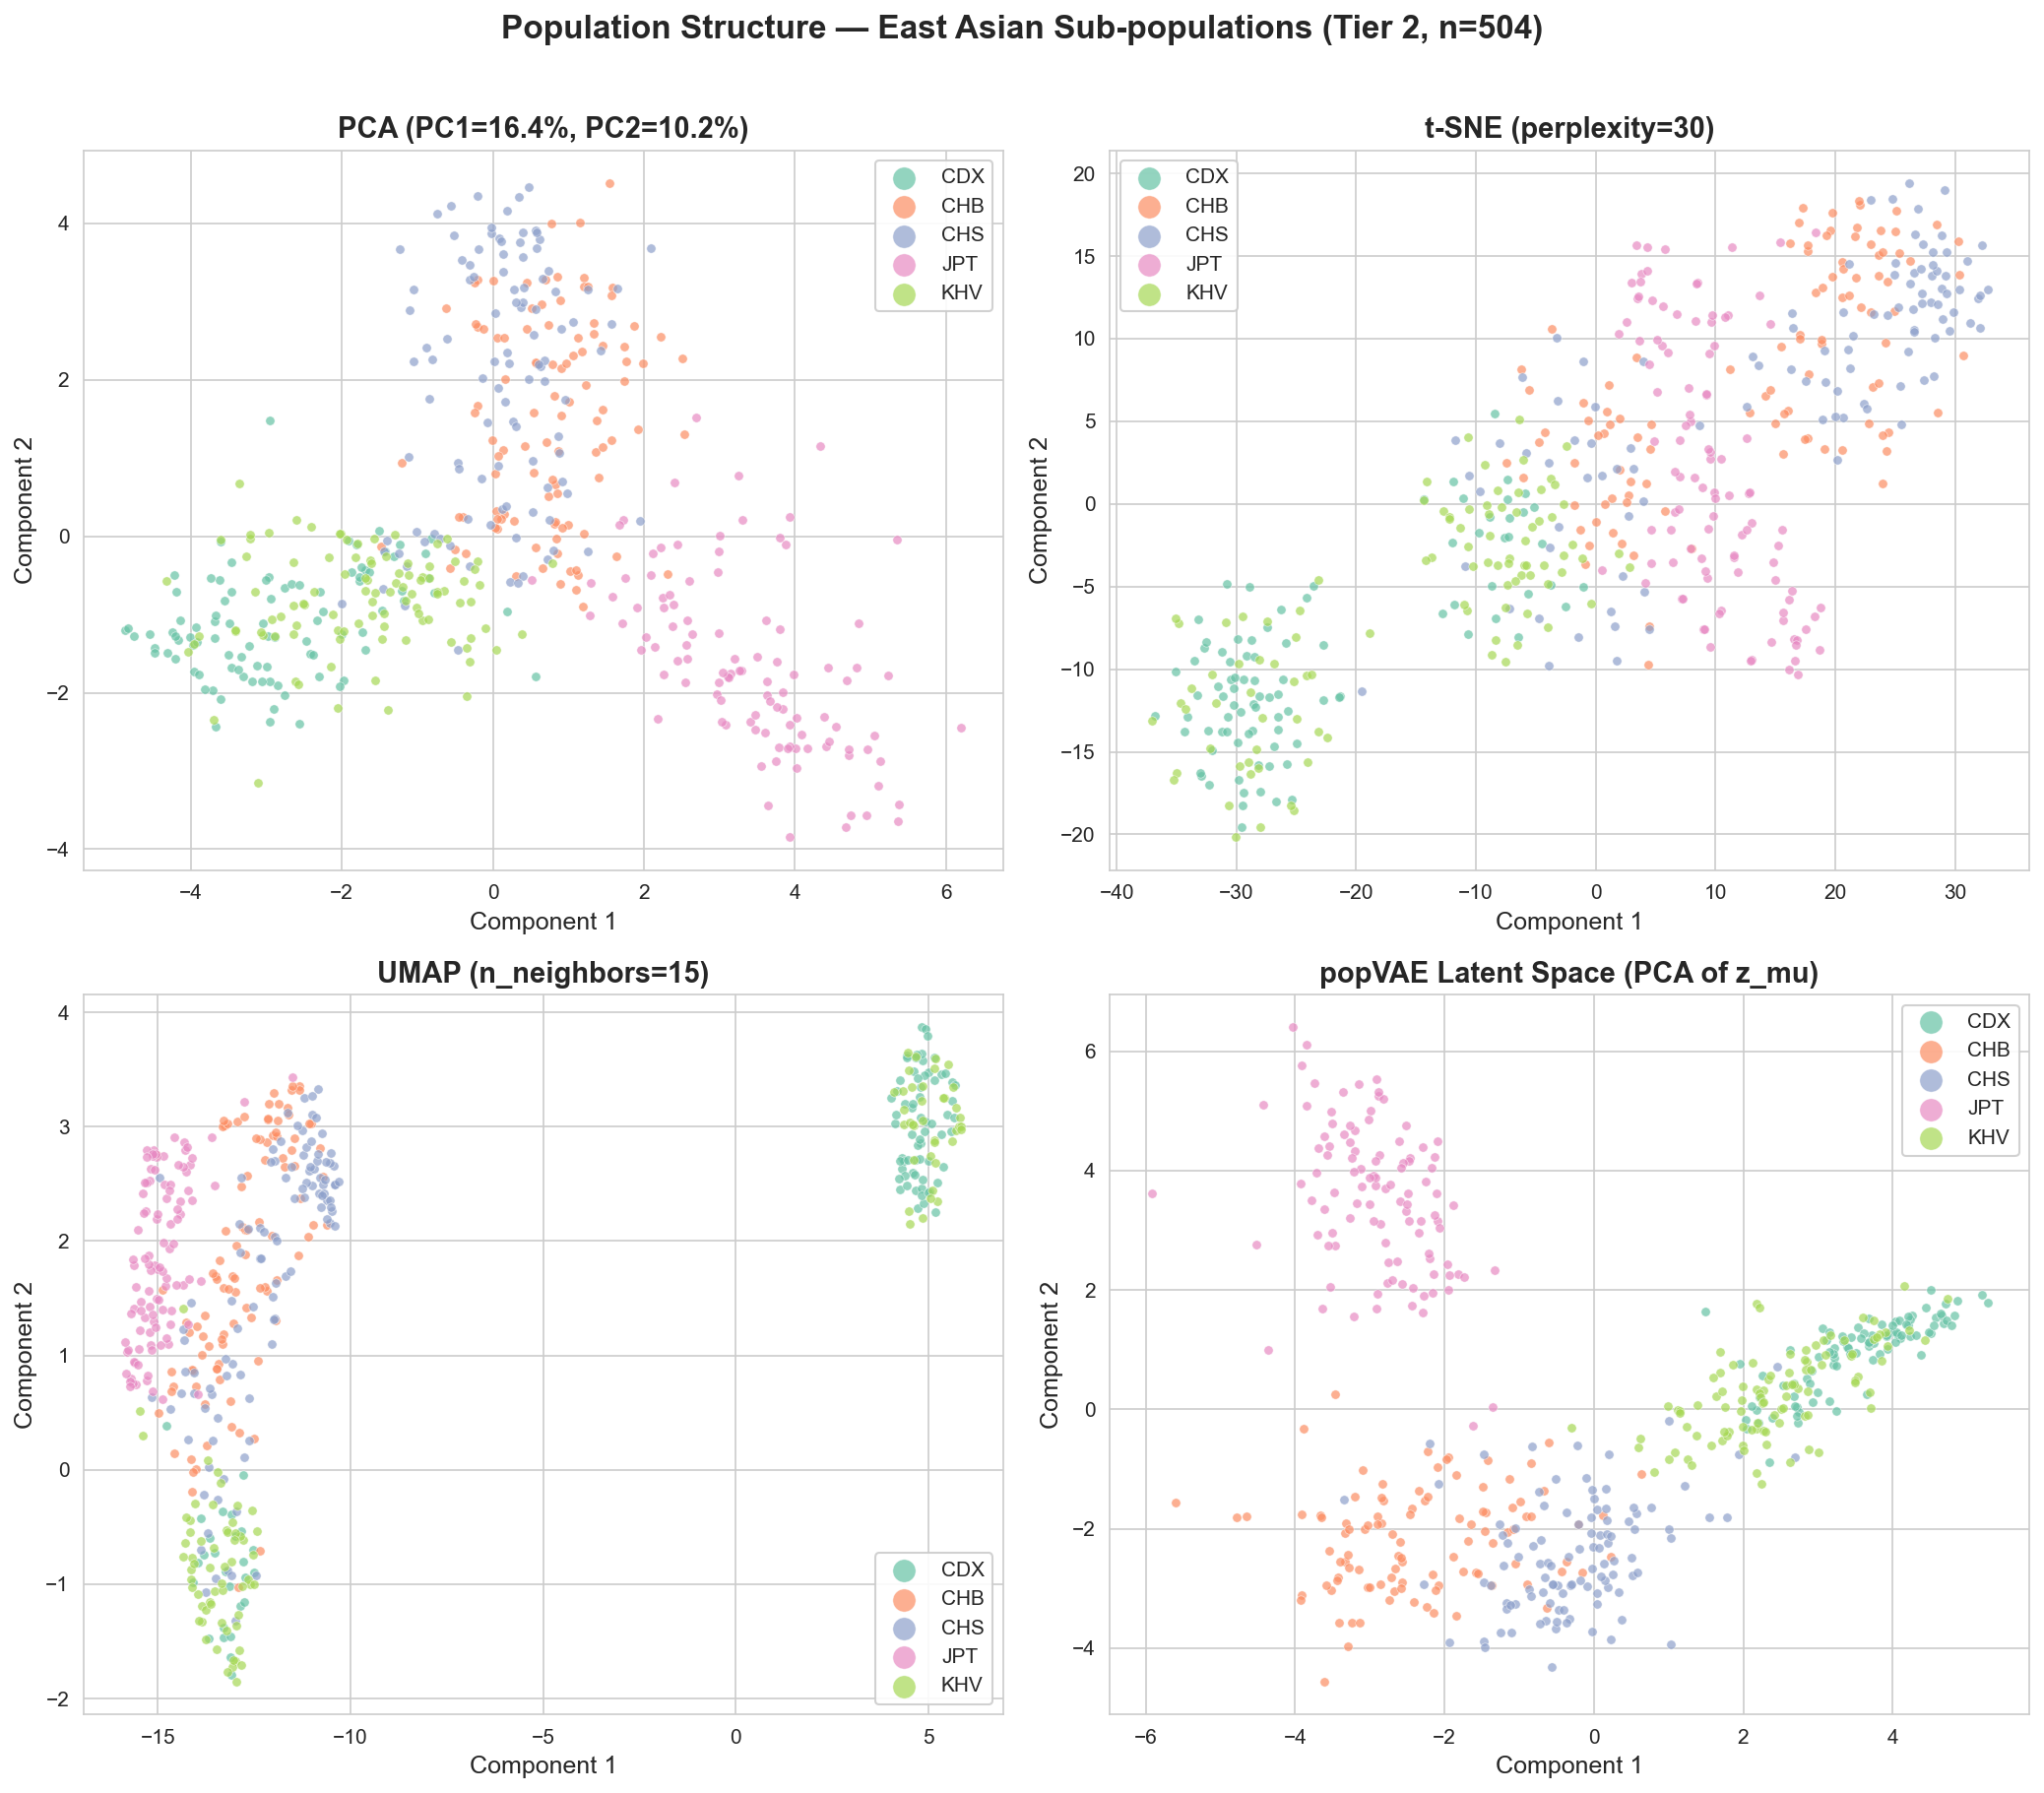

Saved fig2_dimred_tier2_eas.png


In [6]:
labels_eas = np.array([eas_classes[i] for i in y_pop_eas])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
embeddings_eas = [
    (X_pca_eas, f"PCA (PC1={pca_var_eas[0]:.1%}, PC2={pca_var_eas[1]:.1%})"),
    (X_tsne_eas, "t-SNE (perplexity=30)"),
    (X_umap_eas, "UMAP (n_neighbors=15)"),
    (Z_eas_2d, "popVAE Latent Space (PCA of z_mu)"),
]

for ax, (data, title) in zip(axes.flat, embeddings_eas):
    for cls in eas_classes:
        mask = labels_eas == cls
        ax.scatter(data[mask, 0], data[mask, 1], label=cls,
                   c=EAS_COLORS[cls], alpha=0.7, s=20, edgecolors="white", linewidth=0.3)
    ax.set_title(title, fontweight="bold")
    ax.legend(markerscale=2.5, framealpha=0.9, loc="best")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

fig.suptitle("Population Structure — East Asian Sub-populations (Tier 2, n=504)",
             fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_dimred_tier2_eas.png")
plt.show()
print("Saved fig2_dimred_tier2_eas.png")

## Figure 3: Top 20 AISNP Ranking
Feature importance bar charts for Tier 1 (continental) and Tier 2 (East Asian).

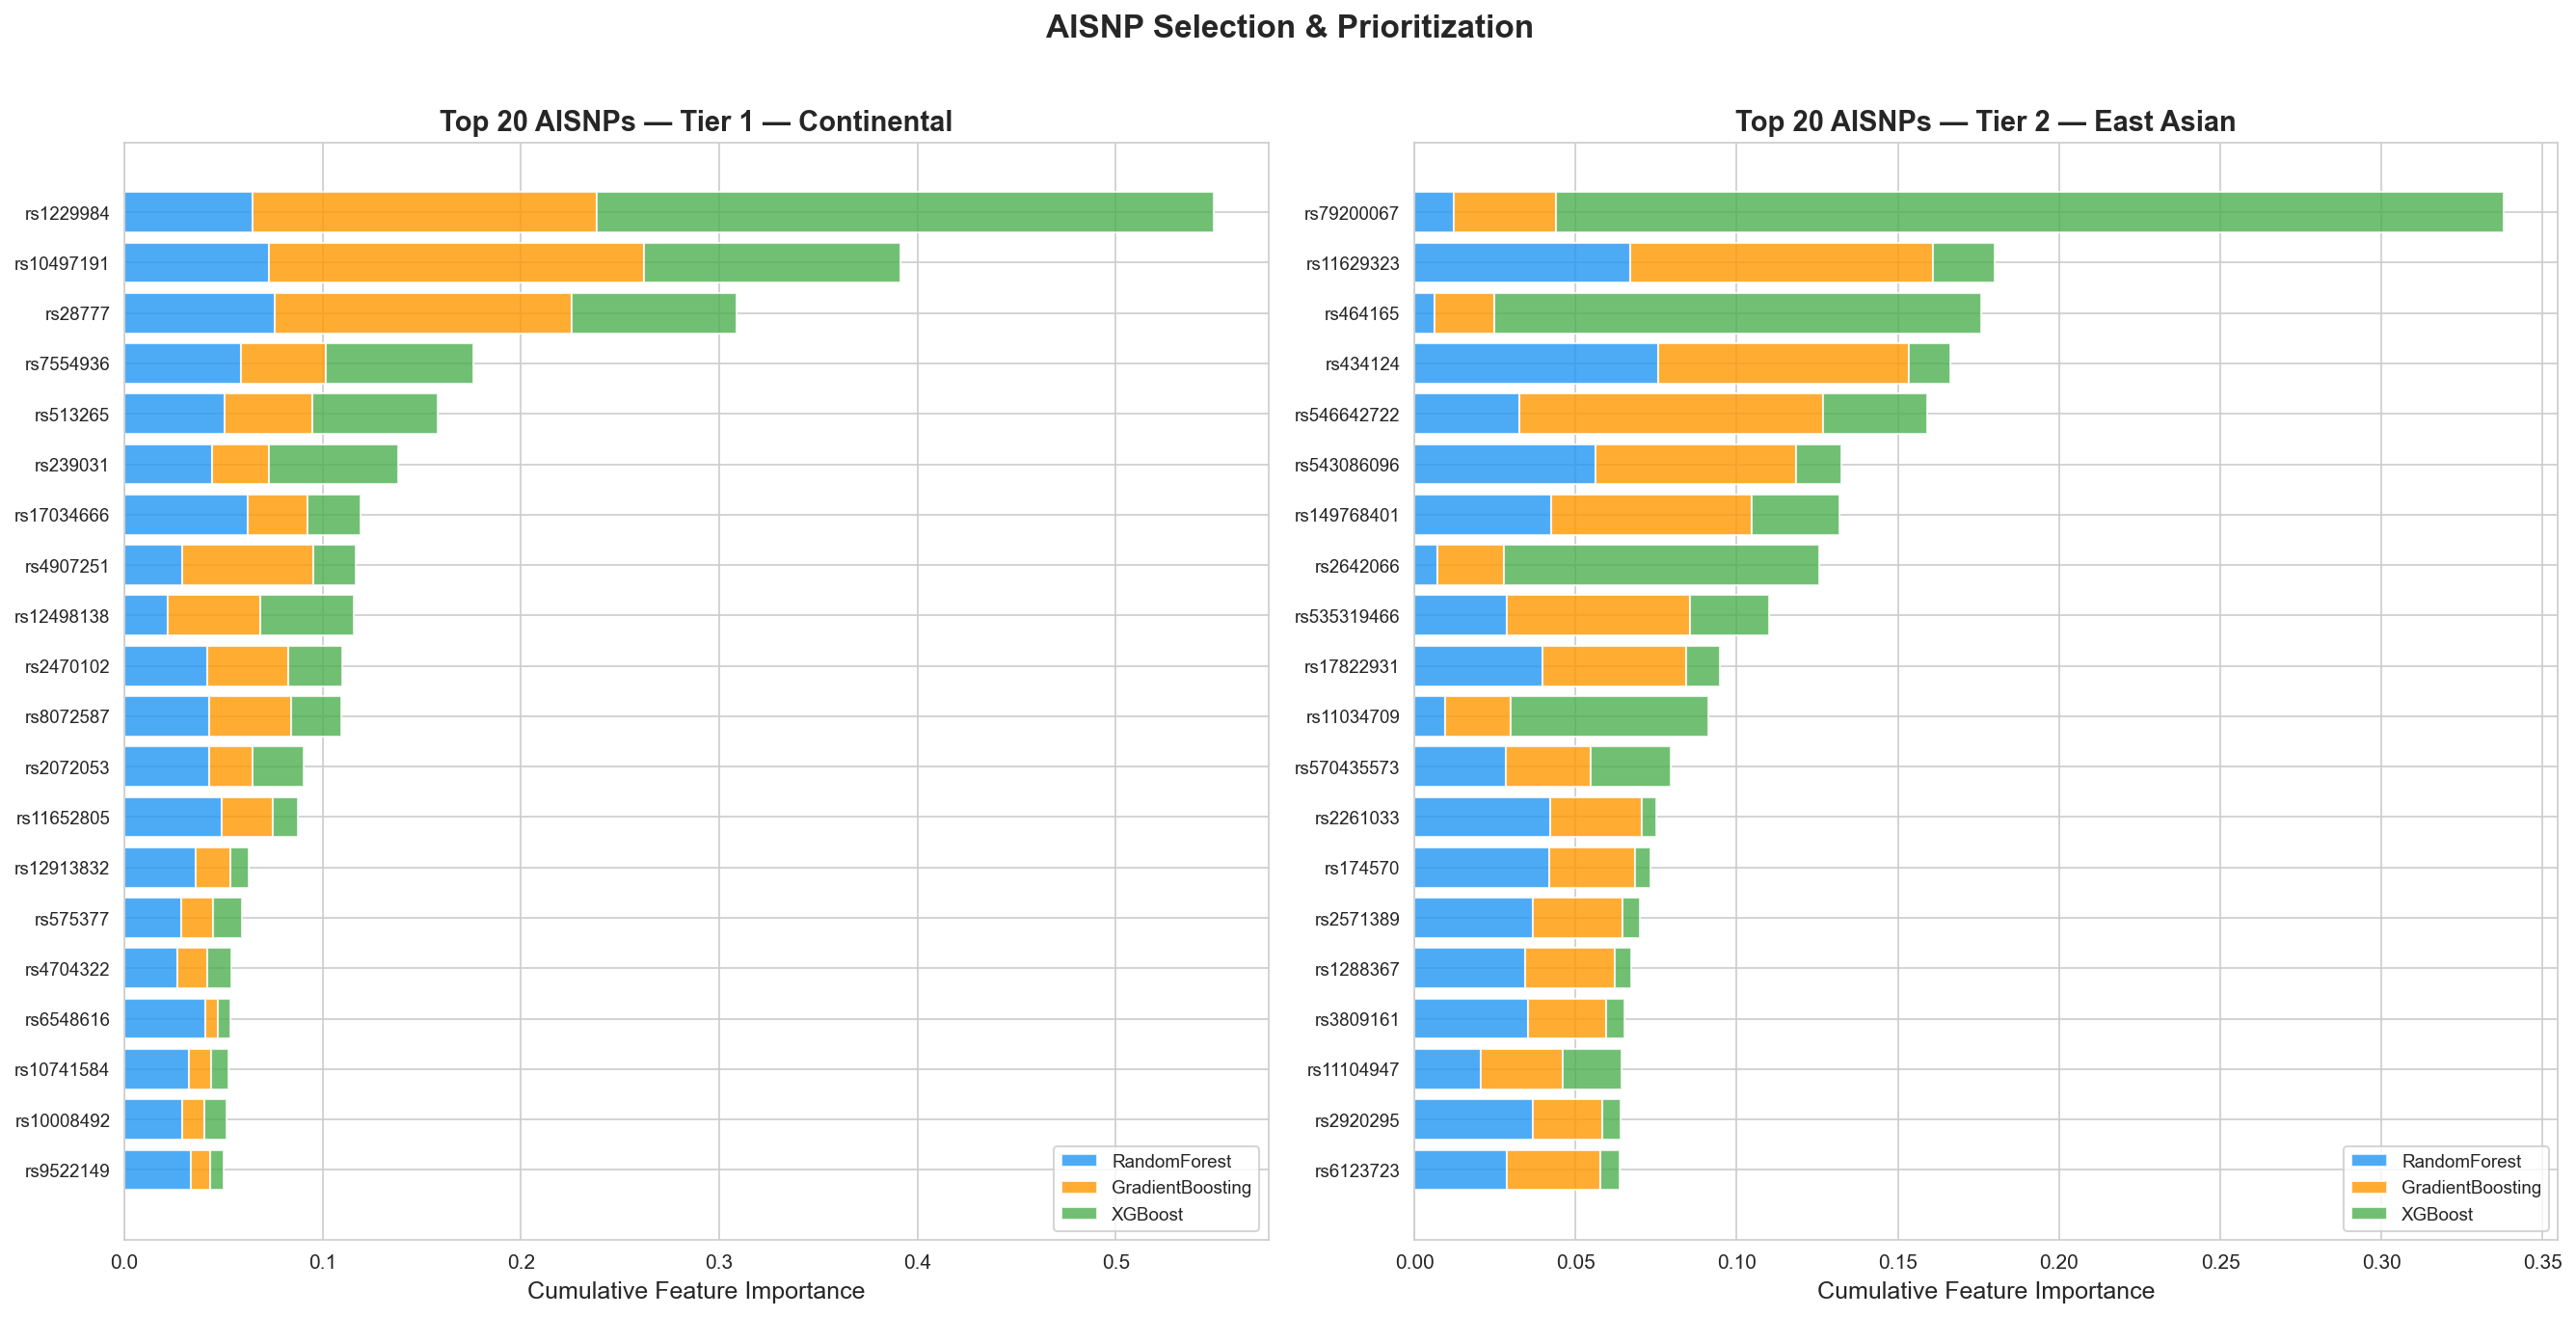

Tier 1 — Top 20 AISNPs:
   1. rs1229984        importance=0.18315
   2. rs10497191       importance=0.13052
   3. rs28777          importance=0.10292
   4. rs7554936        importance=0.05861
   5. rs513265         importance=0.05273
   6. rs239031         importance=0.04606
   7. rs17034666       importance=0.03976
   8. rs4907251        importance=0.03883
   9. rs12498138       importance=0.03855
  10. rs2470102        importance=0.03664
  11. rs8072587        importance=0.03647
  12. rs2072053        importance=0.03017
  13. rs11652805       importance=0.02916
  14. rs12913832       importance=0.02082
  15. rs575377         importance=0.01969
  16. rs4704322        importance=0.01803
  17. rs6548616        importance=0.01789
  18. rs10741584       importance=0.01744
  19. rs10008492       importance=0.01715
  20. rs9522149        importance=0.01663
Tier 2 — Top 20 AISNPs:
   1. rs79200067       importance=0.11263
   2. rs11629323       importance=0.06002
   3. rs464165         impor

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, fi, tier_label in [
    (axes[0], fi_t1, "Tier 1 — Continental"),
    (axes[1], fi_t2, "Tier 2 — East Asian"),
]:
    top20_snps = list(fi["top20_snps"])
    top20_scores = fi["top20_scores"]
    snp_list = list(fi["snp_ids"])
    top20_idx = fi["top20_idx"]

    # Per-model importance for stacked view
    imp_rf = fi["importances_rf"][top20_idx]
    imp_gb = fi["importances_gb"][top20_idx]
    imp_xgb = fi["importances_xgb"][top20_idx]

    y_pos = np.arange(20)
    # Plot stacked bars (reversed for top-to-bottom)
    ax.barh(y_pos, imp_rf[::-1], label="RandomForest", color="#2196F3", alpha=0.8)
    ax.barh(y_pos, imp_gb[::-1], left=imp_rf[::-1], label="GradientBoosting", color="#FF9800", alpha=0.8)
    ax.barh(y_pos, imp_xgb[::-1], left=(imp_rf + imp_gb)[::-1], label="XGBoost", color="#4CAF50", alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top20_snps[::-1], fontsize=9)
    ax.set_xlabel("Cumulative Feature Importance")
    ax.set_title(f"Top 20 AISNPs — {tier_label}", fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)

fig.suptitle("AISNP Selection & Prioritization", fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_top20_aisnp.png")
plt.show()

# Print tables
for fi, tier_label in [(fi_t1, "Tier 1"), (fi_t2, "Tier 2")]:
    print(f"\
{tier_label} — Top 20 AISNPs:")
    for i, (snp, score) in enumerate(zip(fi["top20_snps"], fi["top20_scores"]), 1):
        print(f"  {i:2d}. {snp:15s}  importance={score:.5f}")

## Figure 4: Allele Frequency Heatmaps
Minor allele frequency distribution for top 20 AISNPs across populations.

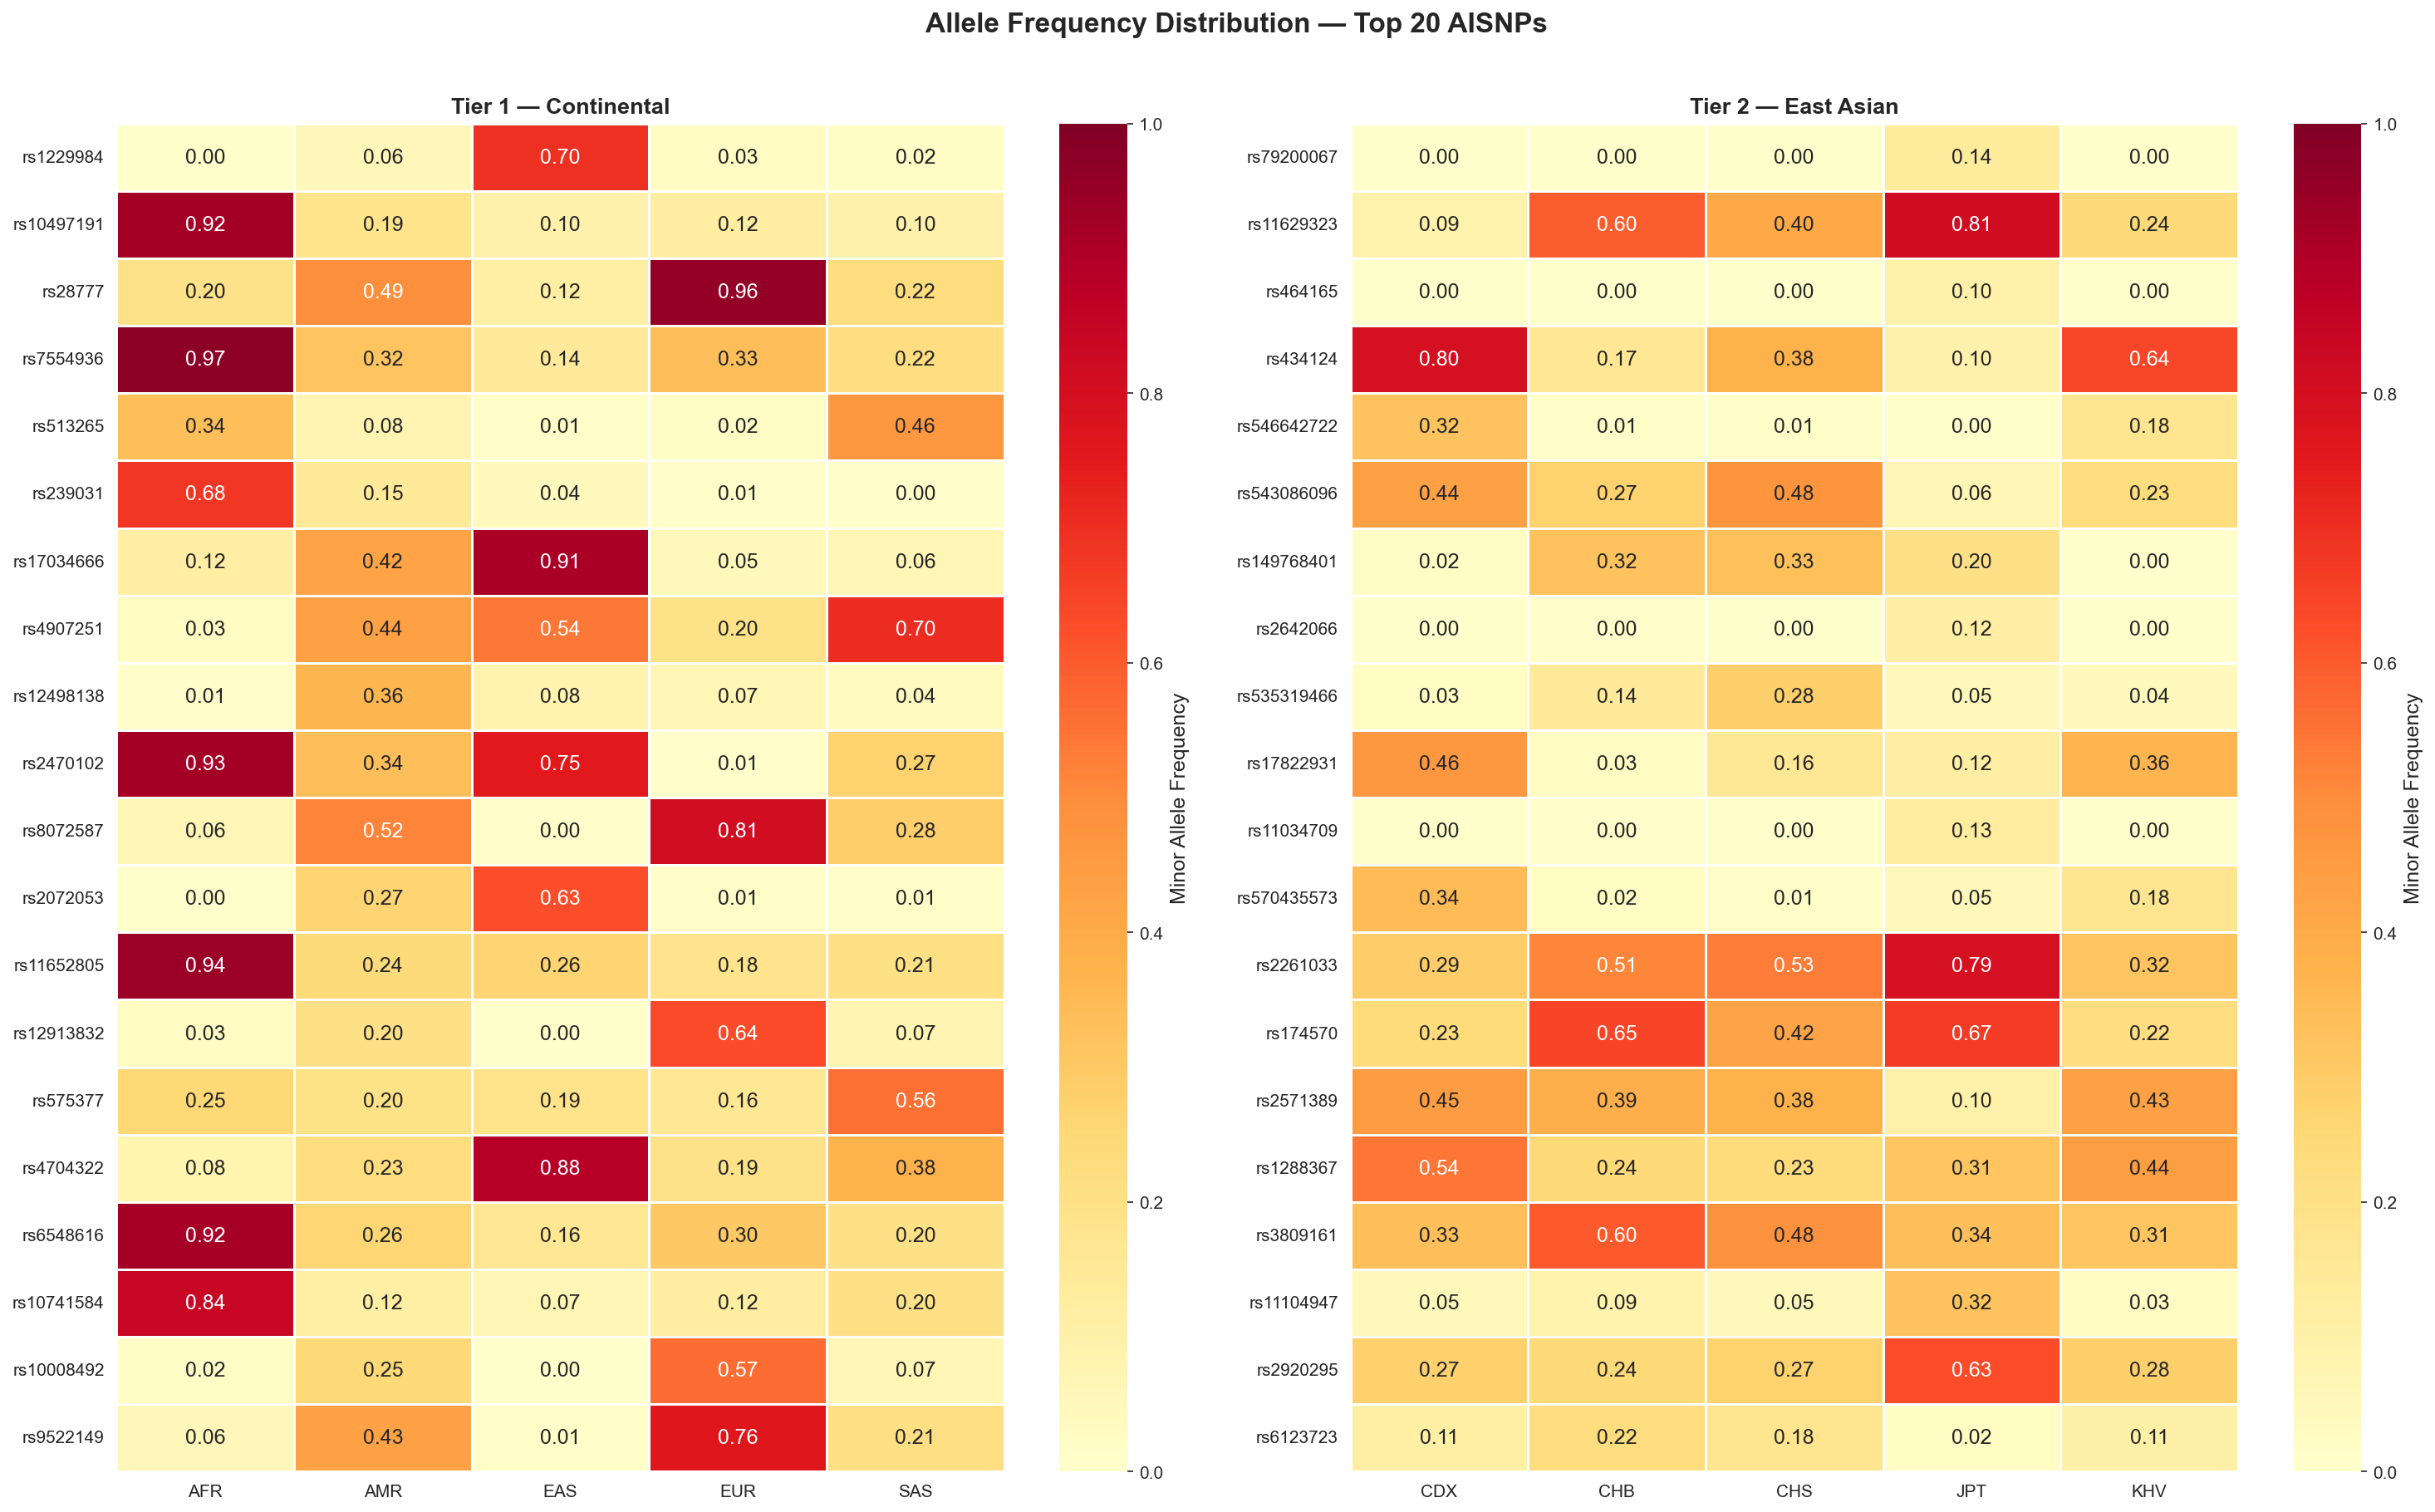

Saved fig4_allele_freq_heatmap.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

for ax, af_df, title in [
    (axes[0], af_t1, "Tier 1 — Continental"),
    (axes[1], af_t2, "Tier 2 — East Asian"),
]:
    mat = af_df.set_index("SNP")
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
                linewidths=0.5, vmin=0, vmax=1,
                cbar_kws={"label": "Minor Allele Frequency"})
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_ylabel("")
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Allele Frequency Distribution — Top 20 AISNPs",
             fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_allele_freq_heatmap.png")
plt.show()
print("Saved fig4_allele_freq_heatmap.png")

## Figure 5: Comprehensive Benchmark — All Models
Accuracy and MCC comparison for all 17+ models across both tiers.

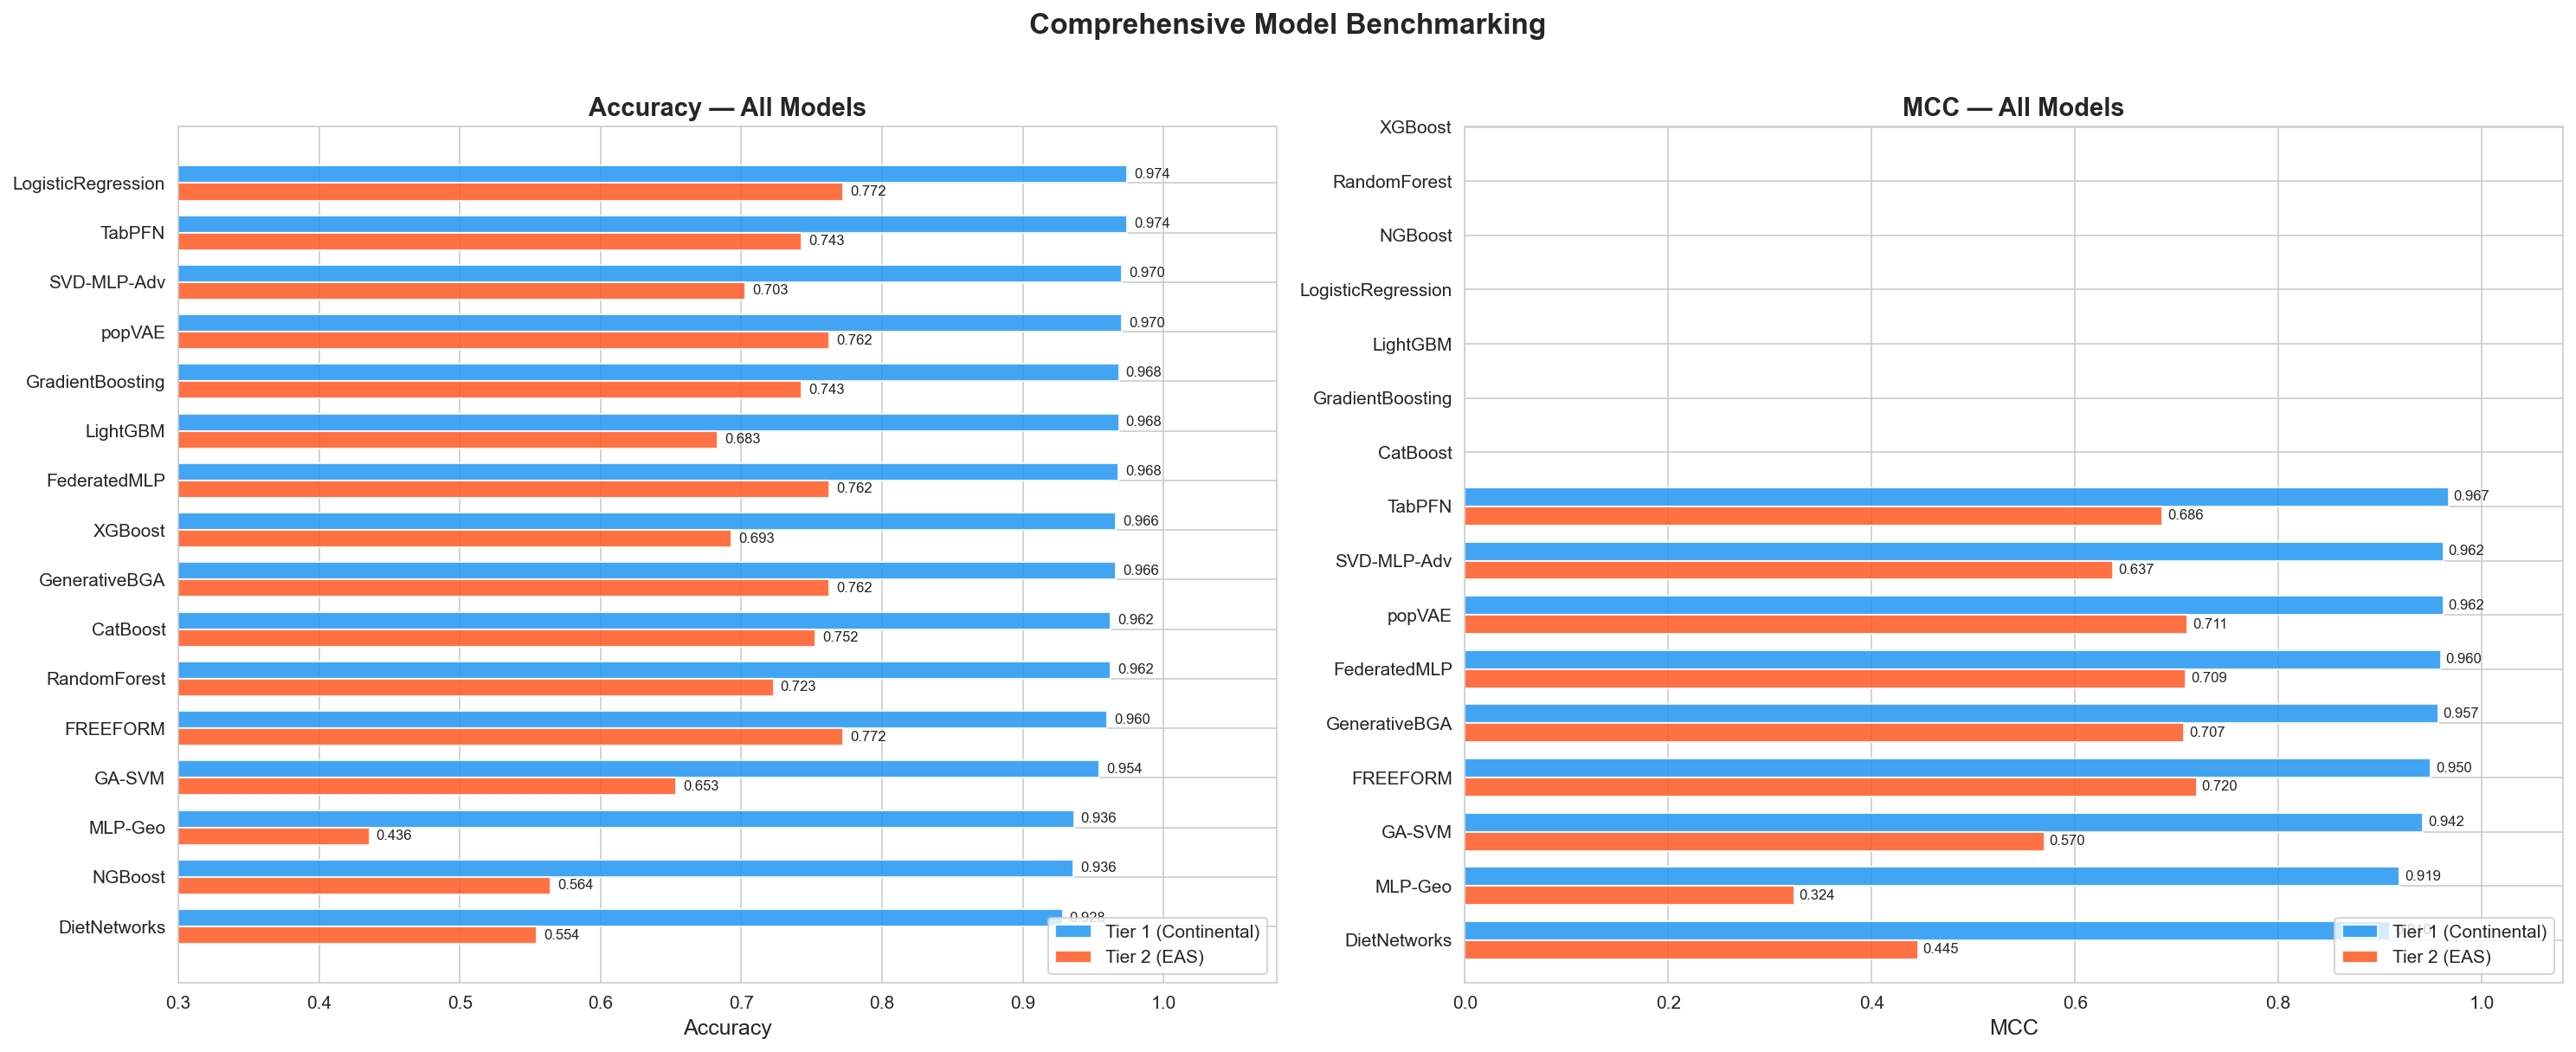

Saved fig5_benchmark_all.png


In [9]:
# Build pivot tables
df_t1 = df_bench[df_bench["tier"] == "tier1"].set_index("model")
df_t2 = df_bench[df_bench["tier"] == "tier2"].set_index("model")

# Find common models
all_models = sorted(set(df_t1.index) | set(df_t2.index))

fig, axes = plt.subplots(1, 2, figsize=(20, max(8, len(all_models) * 0.45)))

for ax, metric, metric_label in [
    (axes[0], "accuracy", "Accuracy"),
    (axes[1], "mcc", "MCC"),
]:
    # Prepare data
    models_sorted = []
    vals_t1, vals_t2 = [], []
    for m in all_models:
        v1 = df_t1.loc[m, metric] if m in df_t1.index else np.nan
        v2 = df_t2.loc[m, metric] if m in df_t2.index else np.nan
        models_sorted.append(m)
        vals_t1.append(v1)
        vals_t2.append(v2)

    # Sort by Tier 1 value
    order = np.argsort(vals_t1)[::-1]
    models_sorted = [models_sorted[i] for i in order]
    vals_t1 = [vals_t1[i] for i in order]
    vals_t2 = [vals_t2[i] for i in order]

    y_pos = np.arange(len(models_sorted))
    bar_h = 0.35
    ax.barh(y_pos - bar_h/2, vals_t1, bar_h, label="Tier 1 (Continental)",
            color="#2196F3", alpha=0.85)
    ax.barh(y_pos + bar_h/2, vals_t2, bar_h, label="Tier 2 (EAS)",
            color="#FF5722", alpha=0.85)

    # Annotate
    for i, (v1, v2) in enumerate(zip(vals_t1, vals_t2)):
        if not np.isnan(v1):
            ax.text(v1 + 0.005, i - bar_h/2, f"{v1:.3f}", va="center", fontsize=8)
        if not np.isnan(v2):
            ax.text(v2 + 0.005, i + bar_h/2, f"{v2:.3f}", va="center", fontsize=8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(models_sorted, fontsize=10)
    ax.set_xlabel(metric_label, fontsize=12)
    ax.set_title(f"{metric_label} — All Models", fontweight="bold")
    ax.legend(loc="lower right")
    ax.invert_yaxis()
    if metric == "accuracy":
        ax.set_xlim(0.3, 1.08)
    else:
        ax.set_xlim(0, 1.08)

fig.suptitle("Comprehensive Model Benchmarking",
             fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_benchmark_all.png")
plt.show()
print("Saved fig5_benchmark_all.png")

## Figure 6: Tier 1 vs Tier 2 Accuracy Drop
Visualize accuracy degradation when moving from continental to sub-population classification.

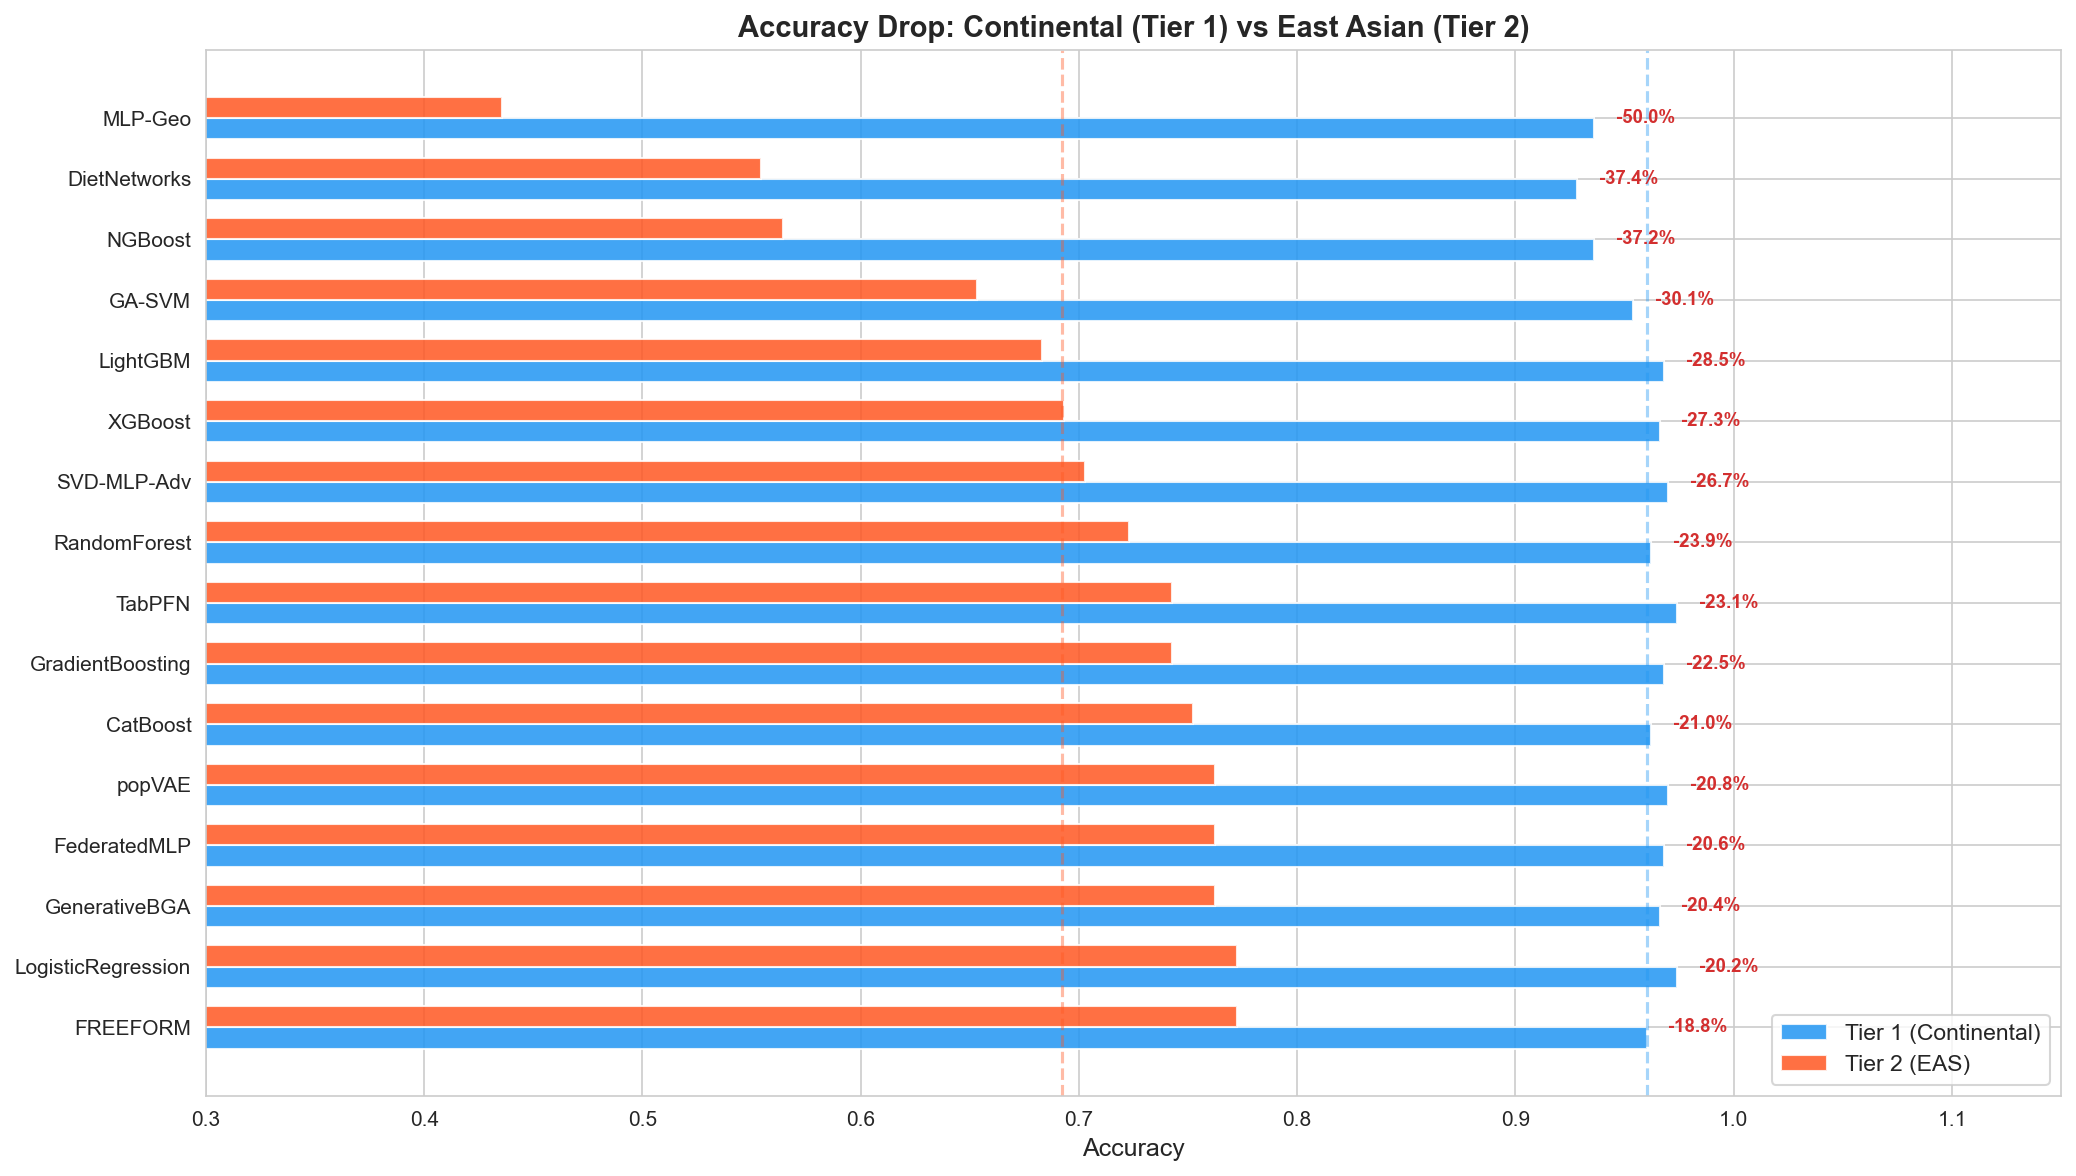

Mean Tier 1 accuracy: 0.9602
Mean Tier 2 accuracy: 0.6925
Mean drop:            0.2678 (26.8%)


In [10]:
# Models present in both tiers
common_models = sorted(set(df_t1.index) & set(df_t2.index))

acc_t1 = [df_t1.loc[m, "accuracy"] for m in common_models]
acc_t2 = [df_t2.loc[m, "accuracy"] for m in common_models]
drops = [t1 - t2 for t1, t2 in zip(acc_t1, acc_t2)]

# Sort by drop magnitude
order = np.argsort(drops)
common_models = [common_models[i] for i in order]
acc_t1 = [acc_t1[i] for i in order]
acc_t2 = [acc_t2[i] for i in order]
drops = [drops[i] for i in order]

fig, ax = plt.subplots(figsize=(14, max(7, len(common_models) * 0.5)))
y_pos = np.arange(len(common_models))
bar_h = 0.35

bars1 = ax.barh(y_pos - bar_h/2, acc_t1, bar_h, label="Tier 1 (Continental)",
                color="#2196F3", alpha=0.85)
bars2 = ax.barh(y_pos + bar_h/2, acc_t2, bar_h, label="Tier 2 (EAS)",
                color="#FF5722", alpha=0.85)

# Annotate drop %
for i, (v1, v2, d) in enumerate(zip(acc_t1, acc_t2, drops)):
    ax.annotate(f"-{d:.1%}",
                xy=(max(v1, v2) + 0.01, i),
                fontsize=9, fontweight="bold", color="#D32F2F", va="center")

ax.set_yticks(y_pos)
ax.set_yticklabels(common_models, fontsize=10)
ax.set_xlabel("Accuracy", fontsize=12)
ax.set_title("Accuracy Drop: Continental (Tier 1) vs East Asian (Tier 2)",
             fontweight="bold", fontsize=14)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim(0.3, 1.15)
ax.axvline(x=np.mean(acc_t1), color="#2196F3", linestyle="--", alpha=0.4, label="_")
ax.axvline(x=np.mean(acc_t2), color="#FF5722", linestyle="--", alpha=0.4, label="_")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_tier1_vs_tier2_drop.png")
plt.show()

print(f"\
Mean Tier 1 accuracy: {np.mean(acc_t1):.4f}")
print(f"Mean Tier 2 accuracy: {np.mean(acc_t2):.4f}")
print(f"Mean drop:            {np.mean(drops):.4f} ({np.mean(drops):.1%})")

## Figure 7: FREEFORM With/Without Comparison
Effect of FREEFORM feature engineering on base model performance.

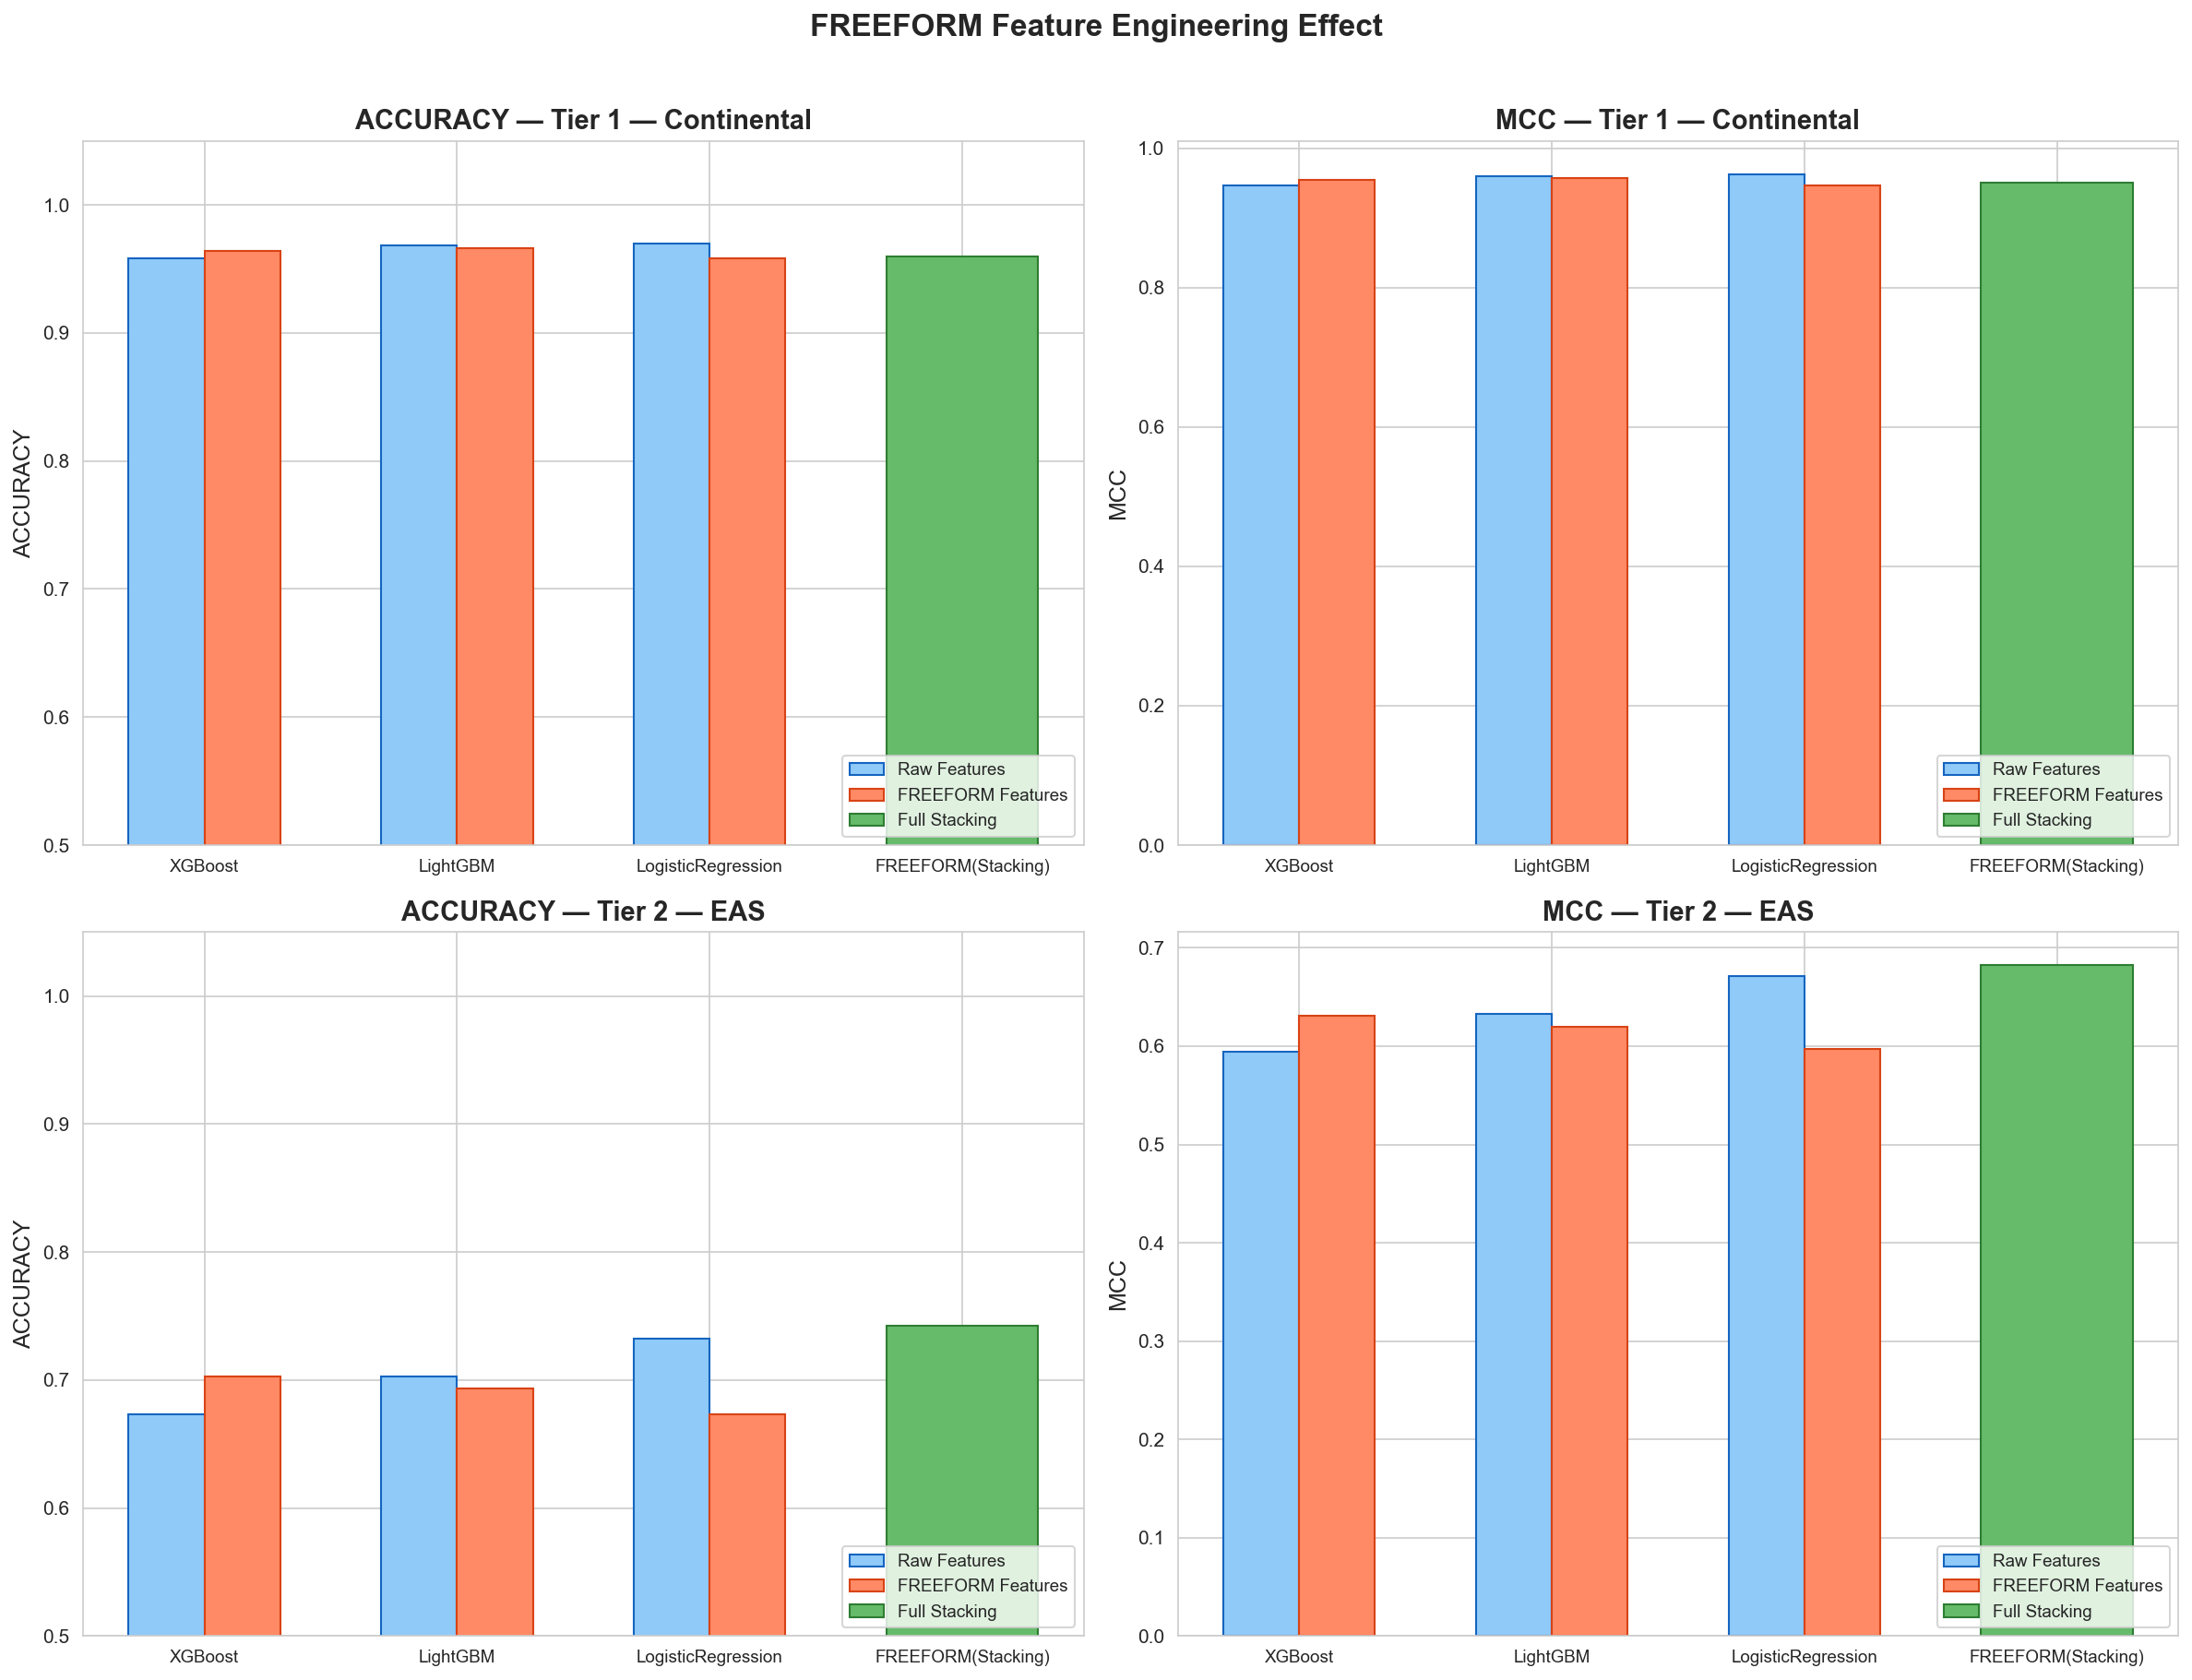

Saved fig7_freeform_comparison.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, (df_ff, tier_label) in enumerate([
    (df_ff_t1, "Tier 1 — Continental"), (df_ff_t2, "Tier 2 — EAS")
]):
    for col, metric in enumerate(["accuracy", "mcc"]):
        ax = axes[row, col]

        # Separate conditions
        df_raw = df_ff[df_ff["condition"] == "Raw Features"]
        df_eng = df_ff[df_ff["condition"] == "FREEFORM Features"]
        df_stack = df_ff[df_ff["condition"] == "Full Stacking"]

        models = list(df_raw["model"])
        x = np.arange(len(models))
        w = 0.3

        raw_vals = list(df_raw[metric])
        eng_vals = list(df_eng[metric])

        ax.bar(x - w/2, raw_vals, w, label="Raw Features", color="#90CAF9", edgecolor="#1565C0")
        ax.bar(x + w/2, eng_vals, w, label="FREEFORM Features", color="#FF8A65", edgecolor="#D84315")

        # Add stacking bar
        if not df_stack.empty:
            stack_val = df_stack[metric].values[0]
            ax.bar(len(models), stack_val, w * 2, label="Full Stacking",
                   color="#66BB6A", edgecolor="#2E7D32")
            ax.set_xticks(list(x) + [len(models)])
            ax.set_xticklabels(models + ["FREEFORM\
(Stacking)"], fontsize=9)
        else:
            ax.set_xticks(x)
            ax.set_xticklabels(models, fontsize=9)

        ax.set_ylabel(metric.upper())
        ax.set_title(f"{metric.upper()} — {tier_label}", fontweight="bold")
        ax.legend(fontsize=9, loc="lower right")
        if metric == "accuracy":
            ax.set_ylim(0.5, 1.05)

fig.suptitle("FREEFORM Feature Engineering Effect",
             fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig7_freeform_comparison.png")
plt.show()
print("Saved fig7_freeform_comparison.png")

## Figure 8: Stacking Ensemble vs Best Single Models
Compare FREEFORM stacking against top individual models.

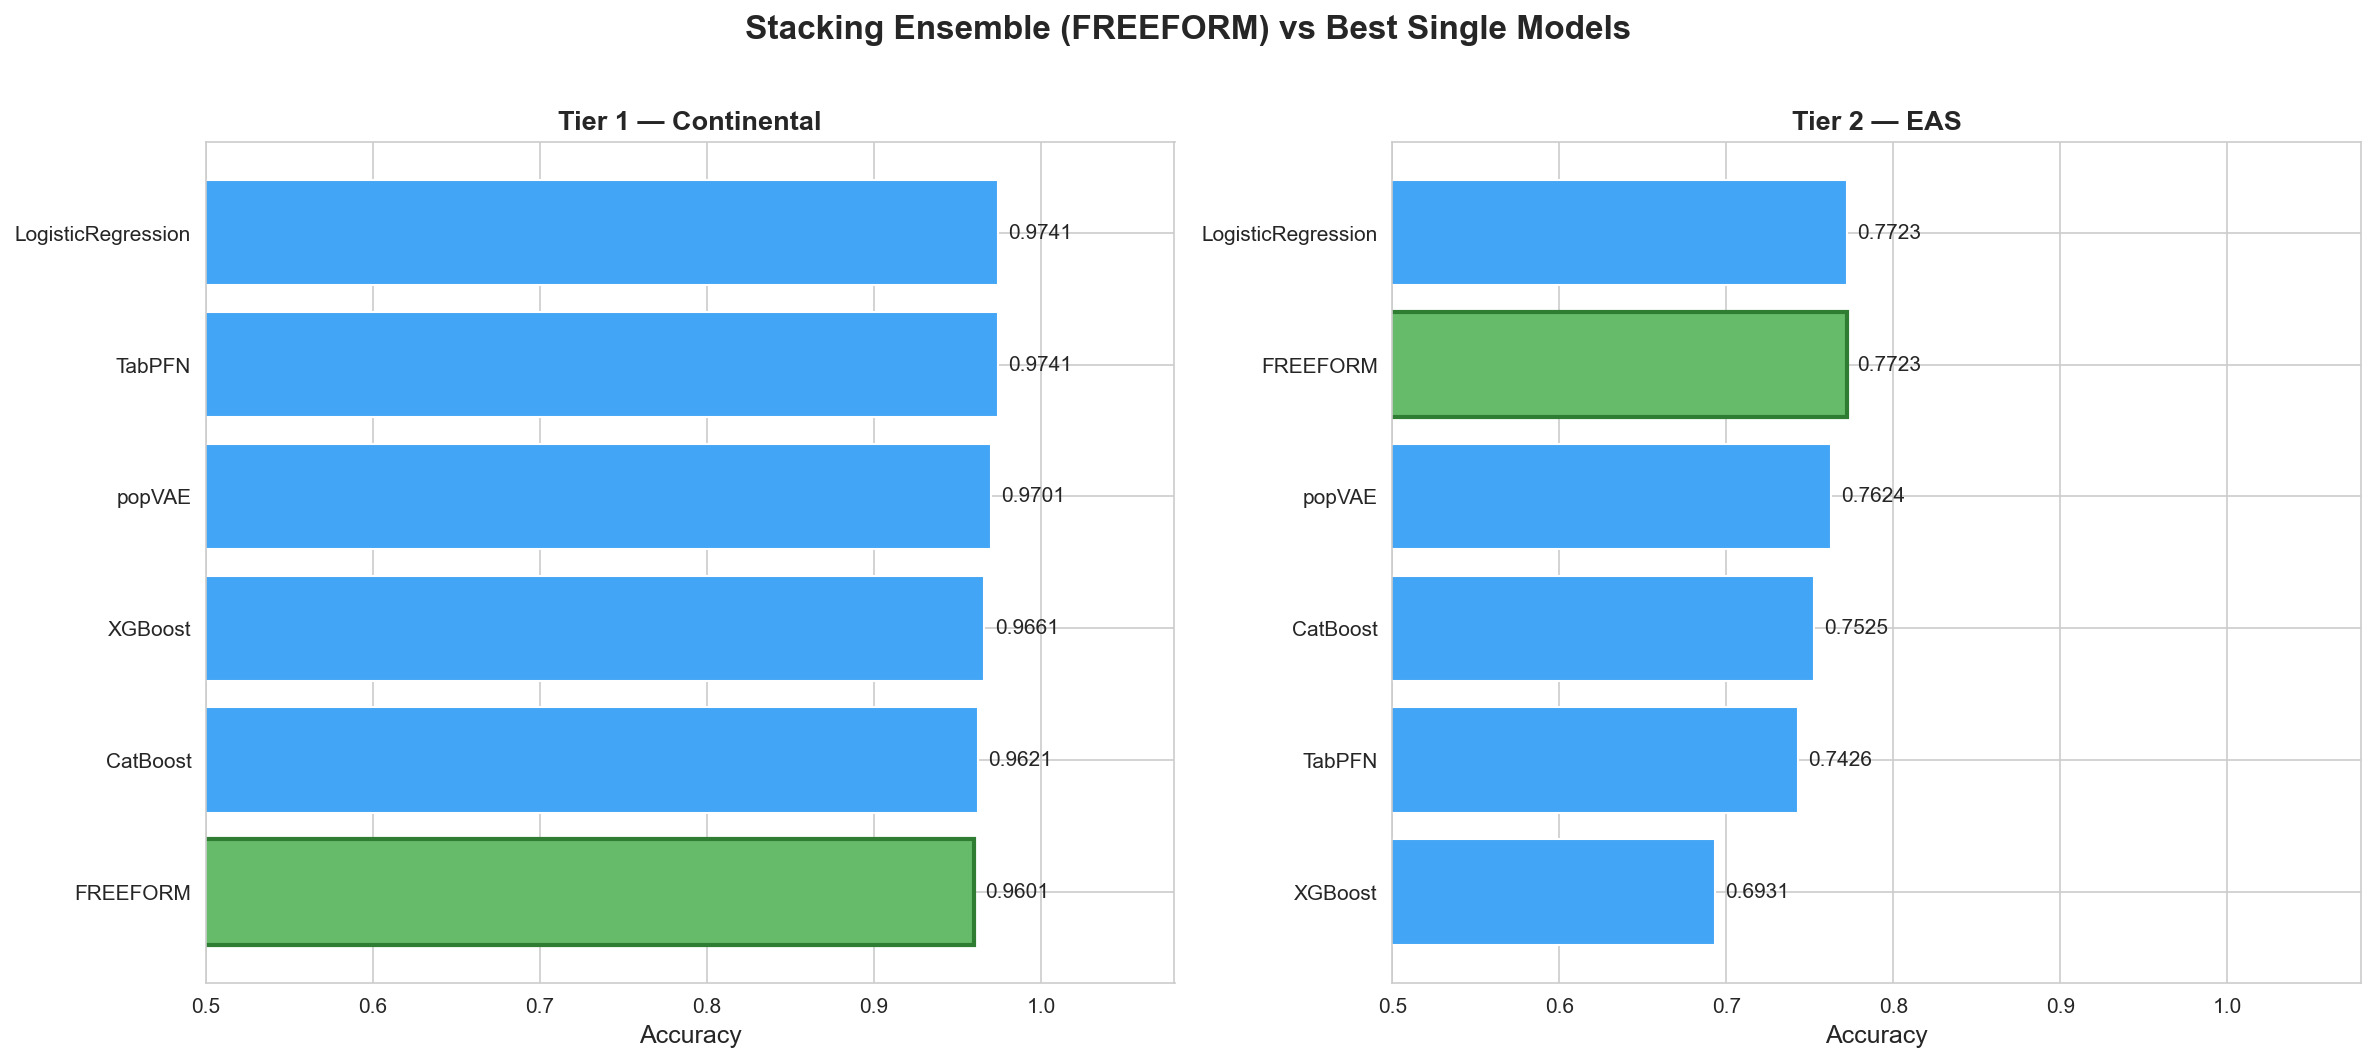

Saved fig8_stacking_vs_best.png


In [12]:
# Select key models to compare
key_models = ["FREEFORM", "CatBoost", "LogisticRegression", "TabPFN", "popVAE", "XGBoost"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, tier, tier_label in [
    (axes[0], "tier1", "Tier 1 — Continental"),
    (axes[1], "tier2", "Tier 2 — EAS"),
]:
    df_tier = df_bench[df_bench["tier"] == tier]
    available = [m for m in key_models if m in df_tier["model"].values]
    df_sel = df_tier[df_tier["model"].isin(available)].sort_values("accuracy", ascending=True)

    colors = ["#66BB6A" if m == "FREEFORM" else "#42A5F5" for m in df_sel["model"]]
    bars = ax.barh(df_sel["model"], df_sel["accuracy"], color=colors, edgecolor="white")
    ax.bar_label(bars, fmt="%.4f", padding=5, fontsize=10)

    ax.set_xlabel("Accuracy", fontsize=12)
    ax.set_title(tier_label, fontweight="bold", fontsize=13)
    ax.set_xlim(0.5, 1.08)

    # Highlight FREEFORM
    for bar, model in zip(bars, df_sel["model"]):
        if model == "FREEFORM":
            bar.set_edgecolor("#2E7D32")
            bar.set_linewidth(2)

fig.suptitle("Stacking Ensemble (FREEFORM) vs Best Single Models",
             fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig8_stacking_vs_best.png")
plt.show()
print("Saved fig8_stacking_vs_best.png")

## Figure 9: Learning Curves — Generative vs Discriminative
Compare XGBoost (discriminative) and Generative Naive Bayes stability across training set sizes.

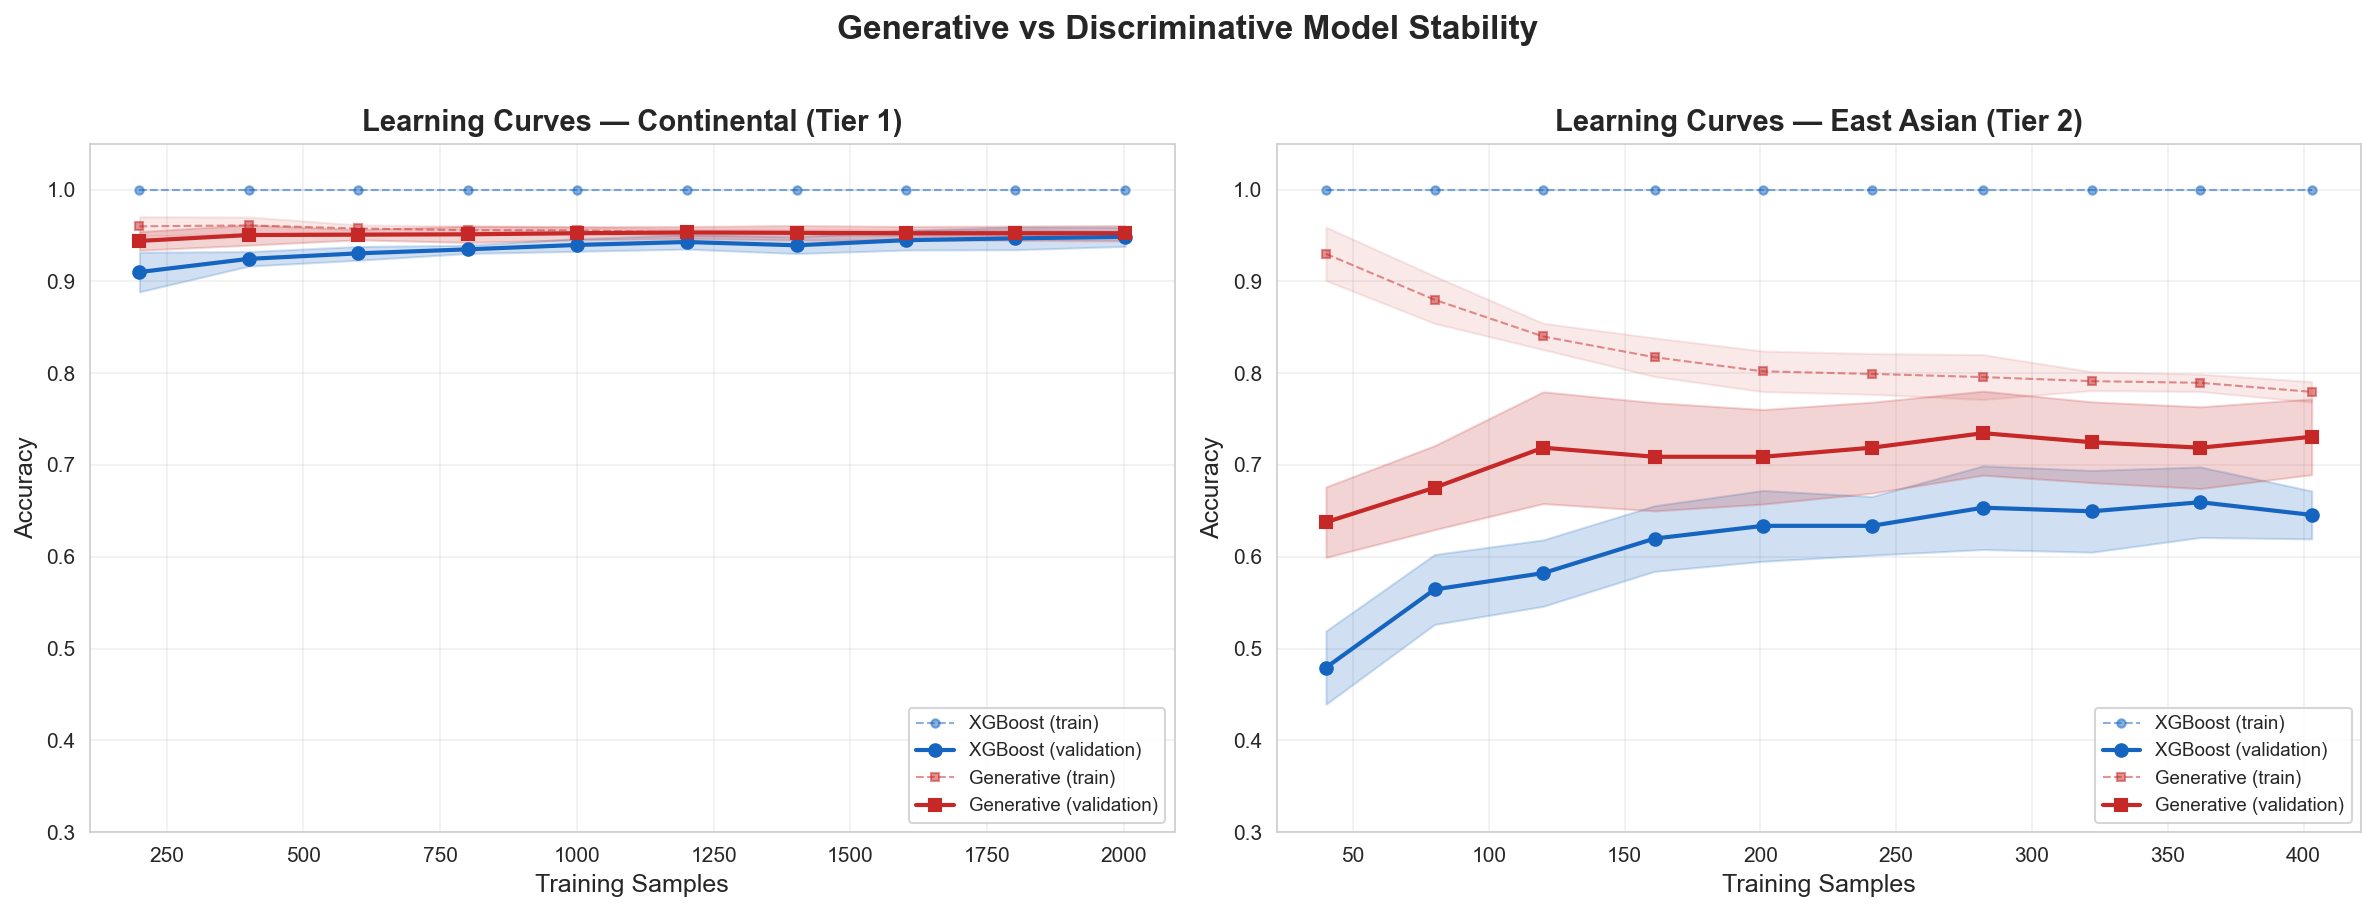

Saved fig9_learning_curves.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_styles = {
    "XGBoost": {"color": "#1565C0", "marker": "o"},
    "Generative": {"color": "#C62828", "marker": "s"},
}

for ax, lc, tier_label in [
    (axes[0], lc_t1, "Continental (Tier 1)"),
    (axes[1], lc_t2, "East Asian (Tier 2)"),
]:
    for model_name, style in model_styles.items():
        sizes = lc[f"{model_name}_sizes"]
        train_mean = lc[f"{model_name}_train_mean"]
        train_std = lc[f"{model_name}_train_std"]
        test_mean = lc[f"{model_name}_test_mean"]
        test_std = lc[f"{model_name}_test_std"]

        # Training curve
        ax.fill_between(sizes, train_mean - train_std, train_mean + train_std,
                        alpha=0.1, color=style["color"])
        ax.plot(sizes, train_mean, f"{style['marker']}--", color=style["color"],
                alpha=0.5, linewidth=1, markersize=4, label=f"{model_name} (train)")

        # Validation curve
        ax.fill_between(sizes, test_mean - test_std, test_mean + test_std,
                        alpha=0.2, color=style["color"])
        ax.plot(sizes, test_mean, f"{style['marker']}-", color=style["color"],
                linewidth=2, markersize=6, label=f"{model_name} (validation)")

    ax.set_xlabel("Training Samples", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.set_title(f"Learning Curves — {tier_label}", fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.3, 1.05)

fig.suptitle("Generative vs Discriminative Model Stability",
             fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig9_learning_curves.png")
plt.show()
print("Saved fig9_learning_curves.png")

## Figure 10: Training Time & Inference Latency
Compare computational efficiency. TabPFN requires no tuning (in-context learning).

NameError: name 'df_timing' is not defined

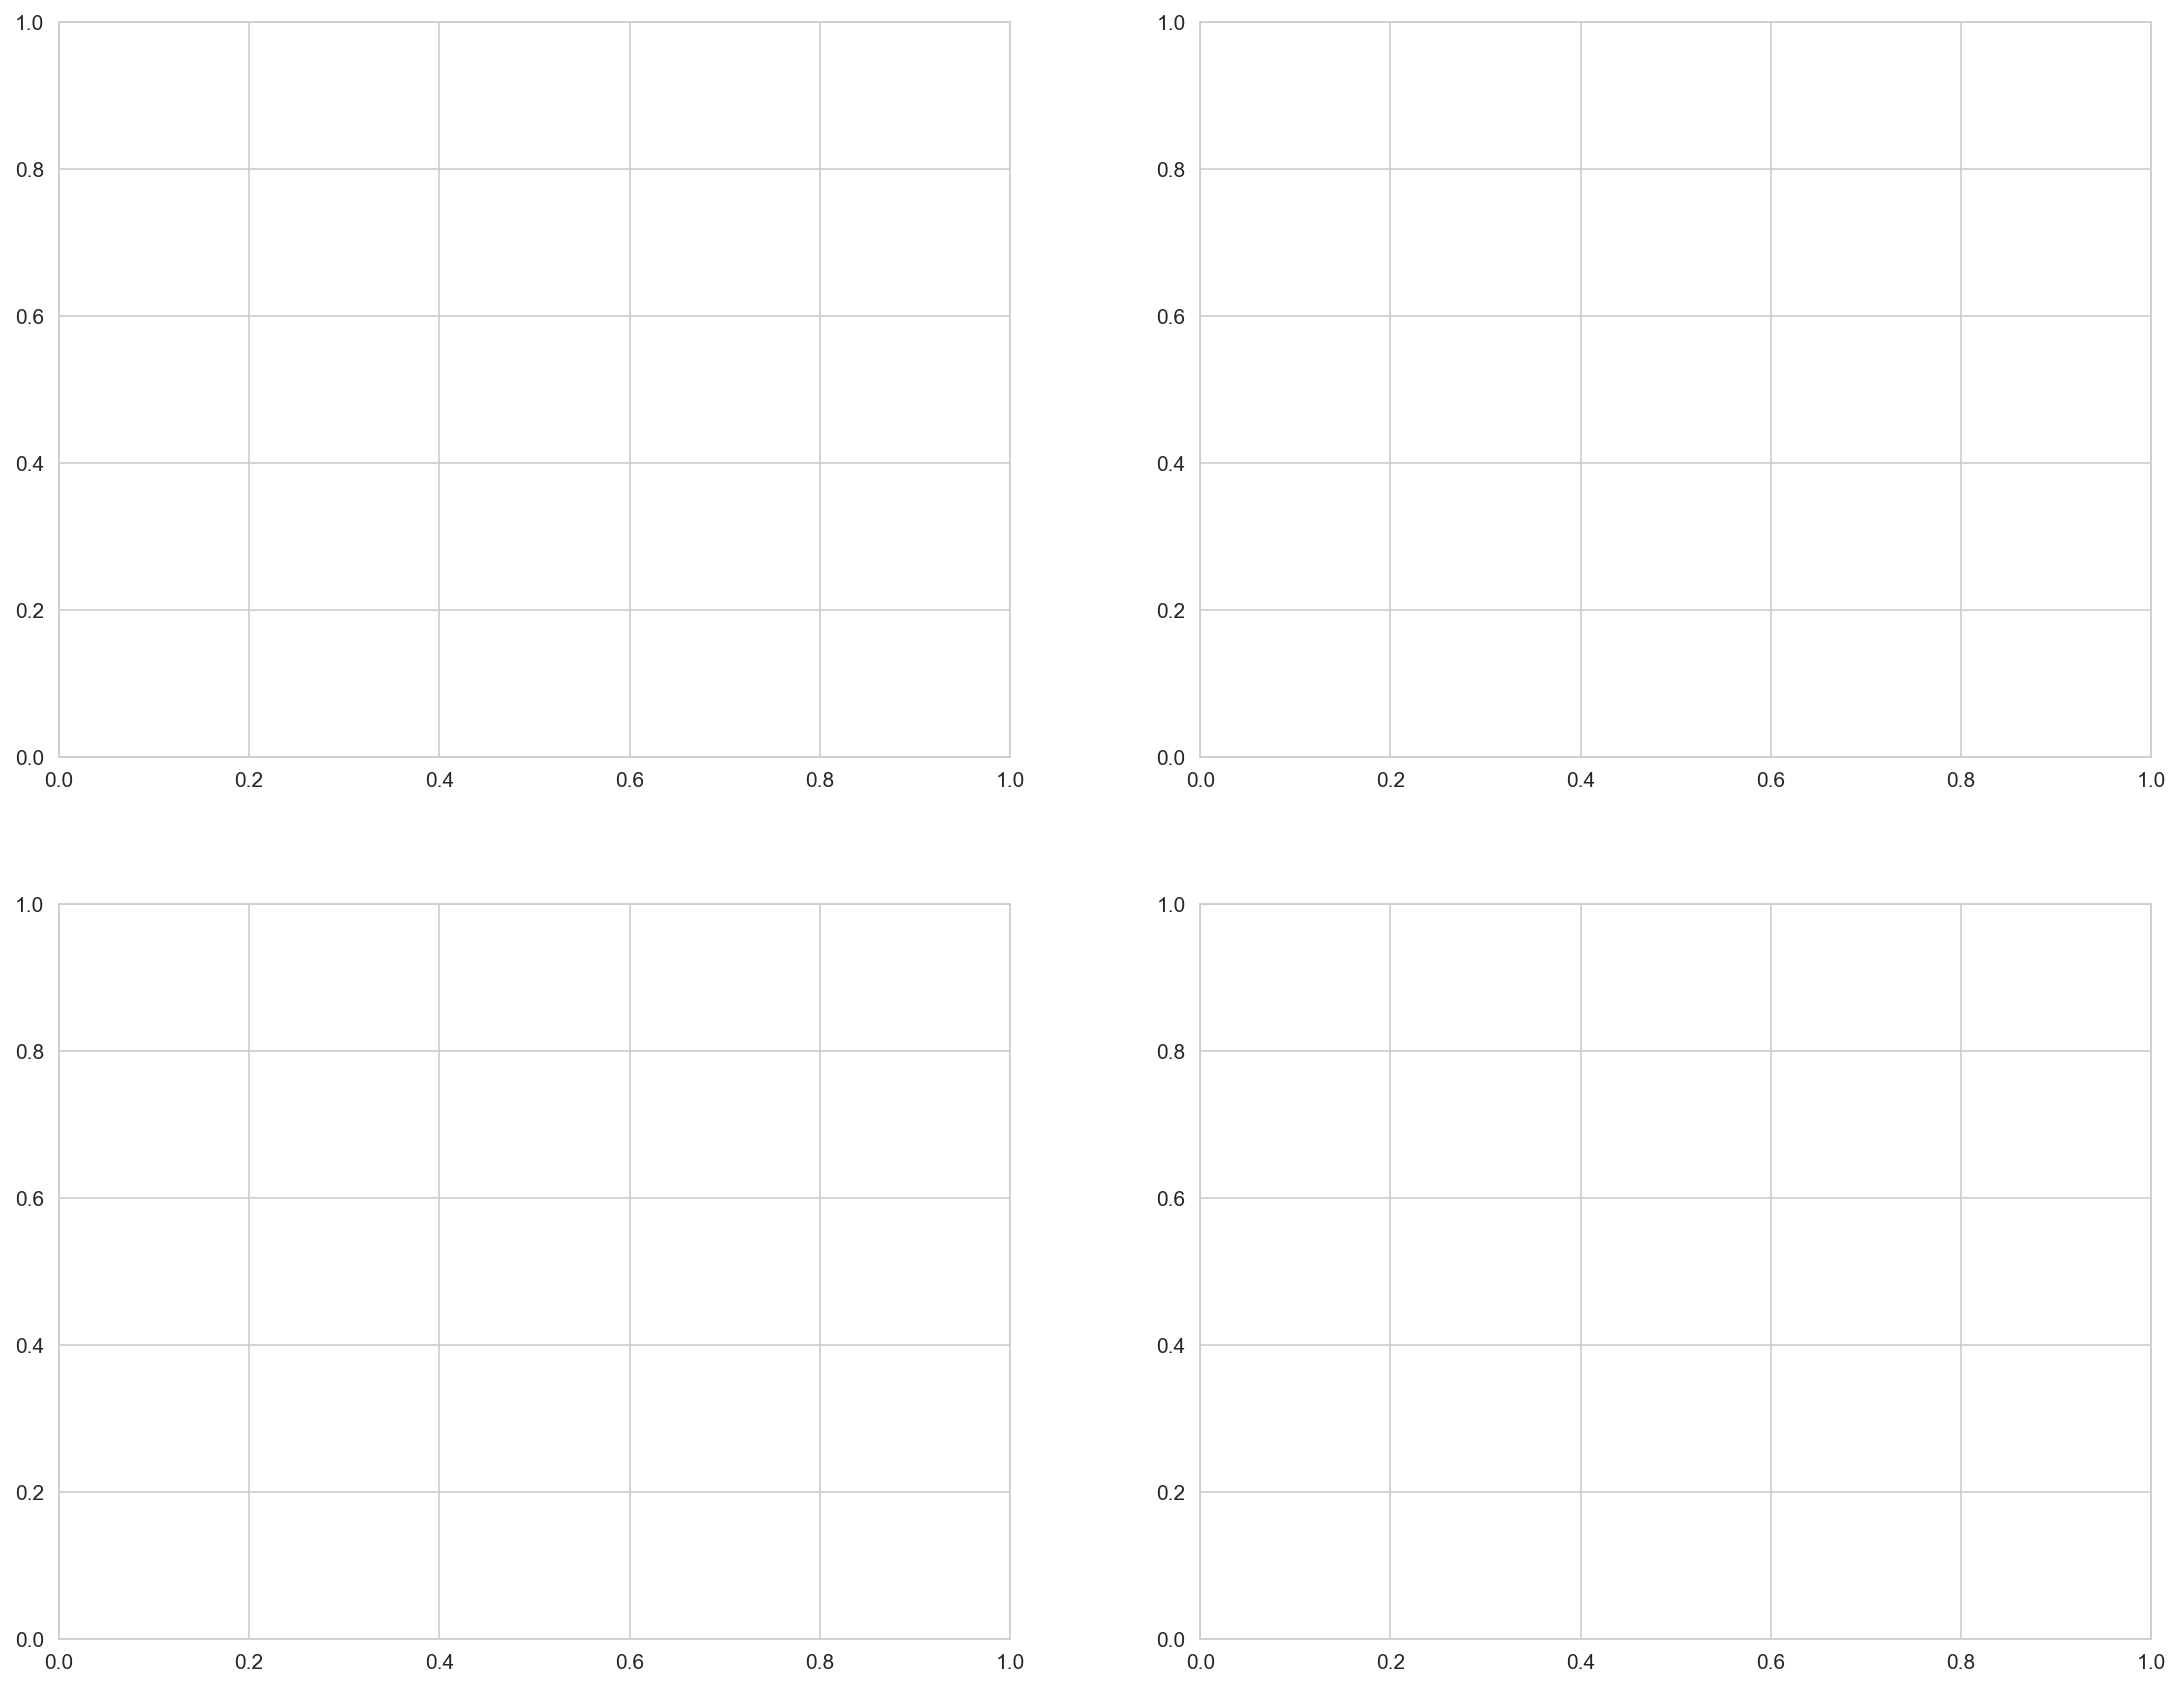

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for row, tier in enumerate(["tier1", "tier2"]):
    df_t = df_timing[df_timing["tier"] == tier].copy()
    tier_label = "Continental (Tier 1)" if tier == "tier1" else "East Asian (Tier 2)"

    # Training time
    ax_train = axes[row, 0]
    df_sorted = df_t.sort_values("train_time_sec", ascending=True)
    colors = ["#FF7043" if not nt else "#42A5F5"
              for nt in df_sorted["needs_tuning"]]
    bars = ax_train.barh(df_sorted["model"], df_sorted["train_time_sec"],
                         color=colors, edgecolor="white")
    ax_train.set_xscale("log")
    ax_train.set_xlabel("Training Time (seconds, log scale)")
    ax_train.set_title(f"Training Time — {tier_label}", fontweight="bold")
    for bar, val in zip(bars, df_sorted["train_time_sec"]):
        ax_train.text(val * 1.1, bar.get_y() + bar.get_height()/2,
                      f"{val:.2f}s", va="center", fontsize=8)

    # Inference latency
    ax_inf = axes[row, 1]
    df_sorted2 = df_t.sort_values("inference_time_mean_sec", ascending=True)
    colors2 = ["#FF7043" if not nt else "#42A5F5"
               for nt in df_sorted2["needs_tuning"]]
    bars2 = ax_inf.barh(df_sorted2["model"], df_sorted2["inference_time_mean_sec"],
                        color=colors2, edgecolor="white",
                        xerr=df_sorted2["inference_time_std_sec"], capsize=3)
    ax_inf.set_xscale("log")
    ax_inf.set_xlabel("Inference Time (seconds, log scale)")
    ax_inf.set_title(f"Inference Latency — {tier_label}", fontweight="bold")
    for bar, val in zip(bars2, df_sorted2["inference_time_mean_sec"]):
        ax_inf.text(val * 1.3, bar.get_y() + bar.get_height()/2,
                    f"{val*1000:.1f}ms", va="center", fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#42A5F5", label="Requires Tuning"),
    Patch(facecolor="#FF7043", label="No Tuning Needed"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, 1.02))

fig.suptitle("Computational Efficiency — Training & Inference",
             fontsize=16, fontweight="bold", y=1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig10_timing_latency.png")
plt.show()
print("Saved fig10_timing_latency.png")

## Summary

All 10 figures saved to `results/figures/`.

| Figure | Description |
|--------|-------------|
| fig1 | Dimensionality Reduction — Continental (Tier 1) |
| fig2 | Dimensionality Reduction — EAS (Tier 2) |
| fig3 | Top 20 AISNP Ranking |
| fig4 | Allele Frequency Heatmaps |
| fig5 | Comprehensive Benchmark (all models) |
| fig6 | Tier 1 vs Tier 2 Accuracy Drop |
| fig7 | FREEFORM With/Without Comparison |
| fig8 | Stacking Ensemble vs Best Single Models |
| fig9 | Learning Curves (Generative vs Discriminative) |
| fig10 | Training Time & Inference Latency |

In [ ]:
saved_figs = sorted(FIG_DIR.glob("*.png"))
print(f"Generated {len(saved_figs)} figures in {FIG_DIR}:\
")
for f in saved_figs:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s}  {size_kb:8.1f} KB")